<a href="https://colab.research.google.com/github/fcoliveira-utfpr/climas_brasil/blob/main/climas_brasil_mapas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificações Climáticas do Brasil — Síntese e Análise Comparativa
### Köppen-Geiger (1936) × Camargo (1991) mod. Maluf (2000) × Thornthwaite (1948)
___

## 0. Bibliotecas e configuração
___

In [1]:
# =========================================================
# BIBLIOTECAS
# =========================================================
!pip install geobr geopandas rasterio elevation cartopy matplotlib-scalebar plotly --quiet

import numpy as np
import pandas as pd
import geopandas as gpd
import geobr
import math

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap, to_rgb
import matplotlib.gridspec as gridspec

import seaborn as sns

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar

import unicodedata
import warnings
from cartopy.io import DownloadWarning
warnings.filterwarnings("ignore", category=DownloadWarning)

from scipy.stats import chi2_contingency, kruskal
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                              cohen_kappa_score)
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

import plotly.graph_objects as go
import plotly.express as px

sns.set_context("notebook")
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 2026


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 68.0 MB/s eta 0:00:00


## 1. Carregamento dos dados
___

In [2]:
urls = {
    "camargo": "https://raw.githubusercontent.com/fcoliveira-utfpr/climas_brasil/refs/heads/main/camargo_municipios_preenchido.csv",
    "koppen":  "https://raw.githubusercontent.com/fcoliveira-utfpr/climas_brasil/refs/heads/main/koppen_municipios_preenchido.csv",
    "thornthwaite": "https://raw.githubusercontent.com/fcoliveira-utfpr/climas_brasil/refs/heads/main/thornthwaite_municipios_preenchido.csv",
}

df_camargo = pd.read_csv(urls["camargo"], sep=",")
df_koppen  = pd.read_csv(urls["koppen"], sep=",")
df_th      = pd.read_csv(urls["thornthwaite"], sep=",")

print("Camargo:", df_camargo.shape)
print("Köppen:", df_koppen.shape)
print("Thornthwaite:", df_th.shape)

Camargo: (5570, 14)
Köppen: (5570, 11)
Thornthwaite: (5570, 16)


In [3]:
def normalize(s):
    if pd.isna(s):
        return ''
    return ''.join(c for c in unicodedata.normalize('NFKD', str(s))
                    if not unicodedata.combining(c)).upper().strip()

STATE_ABBR = {
    'ACRE':'AC','ALAGOAS':'AL','AMAPA':'AP','AMAZONAS':'AM','BAHIA':'BA','CEARA':'CE',
    'DISTRITO FEDERAL':'DF','ESPIRITO SANTO':'ES','GOIAS':'GO','MARANHAO':'MA','MATO GROSSO':'MT',
    'MATO GROSSO DO SUL':'MS','MINAS GERAIS':'MG','PARA':'PA','PARAIBA':'PB','PARANA':'PR',
    'PERNAMBUCO':'PE','PIAUI':'PI','RIO DE JANEIRO':'RJ','RIO GRANDE DO NORTE':'RN',
    'RIO GRANDE DO SUL':'RS','RONDONIA':'RO','RORAIMA':'RR','SANTA CATARINA':'SC','SAO PAULO':'SP',
    'SERGIPE':'SE','TOCANTINS':'TO',
}

UF_NOME = {
    'AC':'Acre','AL':'Alagoas','AP':'Amapá','AM':'Amazonas','BA':'Bahia','CE':'Ceará',
    'DF':'Distrito Federal','ES':'Espírito Santo','GO':'Goiás','MA':'Maranhão','MT':'Mato Grosso',
    'MS':'Mato Grosso do Sul','MG':'Minas Gerais','PA':'Pará','PB':'Paraíba','PR':'Paraná',
    'PE':'Pernambuco','PI':'Piauí','RJ':'Rio de Janeiro','RN':'Rio Grande do Norte',
    'RS':'Rio Grande do Sul','RO':'Rondônia','RR':'Roraima','SC':'Santa Catarina','SP':'São Paulo',
    'SE':'Sergipe','TO':'Tocantins',
}

# ---- Legendas e paletas de cada sistema ----

# Köppen-Geiger (versão completa, 31 classes)
KOPPEN_LABELS = {
    1:'Af',2:'Am',3:'As',4:'Aw',5:'BSh',6:'BSk',7:'BWh',8:'BWk',
    9:'Cfa',10:'Cfb',11:'Cfc',12:'Csa',13:'Csb',14:'Csc',15:'Cwa',16:'Cwb',17:'Cwc',
    18:'Dfa',19:'Dfb',20:'Dfc',21:'Dfd',22:'Dsa',23:'Dsb',24:'Dsc',25:'Dsd',
    26:'Dwa',27:'Dwb',28:'Dwc',29:'Dwd',30:'ET',31:'EF',
}
KOPPEN_COLORS = {
    1:'#0000FF',2:'#0078FF',3:'#46A0FF',4:'#96C8FF',5:'#F5A623',6:'#FFDA8C',7:'#FF0000',8:'#FF9696',
    9:'#C8FF50',10:'#64FF50',11:'#32C800',12:'#FFFF00',13:'#C8C800',14:'#969600',
    15:'#C8FFC8',16:'#96FF96',17:'#64C864',18:'#B4A0FA',19:'#8C78F0',20:'#6450E6',21:'#3C2CB4',
    22:'#E0C8FF',23:'#C8A0FF',24:'#B478FF',25:'#9650FF',26:'#D2D2FF',27:'#AAAAFF',28:'#8282FF',29:'#5A5AFF',
    30:'#B4B4B4',31:'#696969',
}

# Camargo (1991) mod. Maluf (2000)
CM_TERMICO_LABELS = {1:'GL', 2:'FR', 3:'CO', 4:'TE', 5:'STE', 6:'ST', 7:'TR', 8:'EQ'}
CM_TERMICO_NOMES = {
    1:'Gélido', 2:'Frio', 3:'Frio moderado', 4:'Temperado', 5:'Subtemperado',
    6:'Subtropical', 7:'Tropical', 8:'Equatorial'
}
CM_TERMICO_COLORS = {
    1:'#4575b4', 2:'#74add1', 3:'#abd9e9', 4:'#fee08b', 5:'#fdae61', 6:'#f46d43', 7:'#d73027', 8:'#a50026'
}
CM_HIDRICO_LABELS = {1:'DE', 2:'AR', 3:'SE', 4:'MO', 5:'SB', 6:'UM', 7:'PU', 8:'SU'}
CM_HIDRICO_NOMES = {
    1:'Desértico', 2:'Árido', 3:'Seco', 4:'Monçônico', 5:'Subúmido', 6:'Úmido',
    7:'Superúmido', 8:'Extremamente úmido'
}
CM_HIDRICO_COLORS = {
    1:'#8c510a', 2:'#d8b365', 3:'#f6e8c3', 4:'#fee08b', 5:'#c7eae5', 6:'#5ab4ac', 7:'#01807a', 8:'#003c30'
}

# Thornthwaite (1948)
TH_CLASSE_LABELS = {1:'A', 2:'B4', 3:'B3', 4:'B2', 5:'B1', 6:'C2', 7:'C1', 8:'D', 9:'E'}
TH_CLASSE_NOMES = {
    1:'Super-úmido', 2:'Úmido (B4)', 3:'Úmido (B3)', 4:'Úmido (B2)', 5:'Úmido (B1)',
    6:'Subúmido úmido', 7:'Subúmido seco', 8:'Semiárido', 9:'Árido'
}
TH_CLASSE_COLORS = {
    1:'#08306b', 2:'#2171b5', 3:'#4292c6', 4:'#6baed6', 5:'#9ecae1',
    6:'#fee391', 7:'#fec44f', 8:'#fe9929', 9:'#cc4c02'
}

In [4]:
municipios_gdf = geobr.read_municipality(code_muni='all', year=2020).to_crs(epsg=4326)
estados_gdf = geobr.read_state(code_state='all', year=2020).to_crs(epsg=4326)
print(f'geobr trouxe {len(municipios_gdf)} municípios e {len(estados_gdf)} estados.')

municipios_gdf['pt_interno'] = municipios_gdf.geometry.representative_point()
municipios_gdf['lon_c'] = municipios_gdf['pt_interno'].x
municipios_gdf['lat_c'] = municipios_gdf['pt_interno'].y
municipios_gdf['municipio_norm'] = municipios_gdf['name_muni'].apply(normalize)
municipios_gdf['uf'] = municipios_gdf['abbrev_state']


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
municipalities_2020_simplified.parquet: 100%|██████████| 20.2M/20.2M [00:00<00:00, 142MB/s]


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
states_2020_simplified.parquet: 100%|██████████| 1.72M/1.72M [00:00<00:00, 23.0MB/s]

geobr trouxe 5570 municípios e 27 estados.


### 1.1 Merge dos três sistemas em uma única tabela

Os três CSVs compartilham a chave `code_muni`. Algumas colunas contínuas (temperatura,
precipitação, deficiência hídrica etc.)

In [5]:
gdf = municipios_gdf.merge(df_koppen, on='code_muni', how='left')
gdf = gdf.merge(df_camargo, on='code_muni', how='left', suffixes=('', '_cm'))
gdf = gdf.merge(df_th, on='code_muni', how='left', suffixes=('', '_th'))

print('Municípios com Köppen:      ', gdf['classe_koppen_codigo'].notna().sum(), '/', len(gdf))
print('Municípios com Camargo:     ', gdf['cm_termico_codigo'].notna().sum(), '/', len(gdf))
print('Municípios com Thornthwaite:', gdf['th_classe_codigo'].notna().sum(), '/', len(gdf))

gdf.head()

Municípios com Köppen:       5570 / 5570
Municípios com Camargo:      5570 / 5570
Municípios com Thornthwaite: 5570 / 5570


,code_muni,name_muni_x,code_state,abbrev_state_x,name_state,code_region,name_region,year,geometry,pt_interno,...,th_subtipo,th_pety,th_petr,def_anual_mm_th,excedente_anual_mm_th,pet_anual_mm,indice_umidade_im,indice_hidrico_ih,indice_aridez_ia,preenchido_por_vizinho_th
0,1100015.0,Alta Floresta d'Oeste,11.0,RO,Rondônia,1.0,Norte,2020.0,"POLYGON ((-62.19929 -11.82788, -62.18945 -11.8...",POINT (-62.13708 -12.47687),...,w,A',a',212.139999,557.433331,1200.913322,35.818516,46.417449,17.664888,False
1,1100023.0,Ariquemes,11.0,RO,Rondônia,1.0,Norte,2020.0,"POLYGON ((-62.53648 -9.73222, -62.52765 -9.736...",POINT (-63.0562 -9.97811),...,r,B4',a',152.420000,1189.166675,1122.466667,97.794857,105.942271,13.579022,False
2,1100031.0,Cabixi,11.0,RO,Rondônia,1.0,Norte,2020.0,"POLYGON ((-60.37119 -13.36655, -60.37661 -13.3...",POINT (-60.67754 -13.50588),...,w,A',b4',238.443335,600.599997,1283.699997,35.641816,46.786632,18.574693,False
3,1100049.0,Cacoal,11.0,RO,Rondônia,1.0,Norte,2020.0,"POLYGON ((-61.00059 -10.99224, -61.00103 -11.3...",POINT (-61.25092 -11.2239),...,w,A',a',195.323335,997.233310,1165.989990,75.475717,85.526747,16.751716,False
4,1100056.0,Cerejeiras,11.0,RO,Rondônia,1.0,Norte,2020.0,"POLYGON ((-61.50149 -13.00501, -61.49426 -13.0...",POINT (-61.20355 -13.18329),...,w,A',b4',260.886671,518.200001,1270.053329,28.476599,40.801436,20.541395,False


## 2. Funções de mapa
___

In [6]:
def _base_map(ax, titulo):
    minx, miny, maxx, maxy = municipios_gdf.total_bounds
    dx = (maxx - minx) * 0.05; dy = (maxy - miny) * 0.05
    ax.set_extent([minx - dx, maxx + dx, miny - dy, maxy + dy], crs=ccrs.PlateCarree())
    ax.set_anchor('S')   # <<< NOVO: ancora o mapa na base do eixo, elimina espaço em branco acima/abaixo
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    return minx, miny, maxx, maxy

def _decoracoes(ax, minx, miny, maxx, maxy):
    estados_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8,
                               transform=ccrs.PlateCarree(), zorder=5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 9}; gl.ylabel_style = {'size': 9}
    ax.annotate('N', xy=(0.95, 0.13), xytext=(0.95, 0.07), xycoords='axes fraction',
                textcoords='axes fraction', ha='center', va='center', fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='-|>', linewidth=1.3, color='black'))
    lat_media = (miny + maxy) / 2
    dx_m = 111320 * np.cos(np.deg2rad(lat_media))
    largura_km = (maxx - minx) * dx_m / 1000
    escolhas_km = [10, 20, 25, 50, 100, 150, 200, 250, 500, 750, 1000]
    fixo_km = min(escolhas_km, key=lambda x: abs(x - largura_km / 4))
    ax.add_artist(ScaleBar(dx=dx_m, units='m', fixed_value=fixo_km * 1000, location='lower left',
                            box_alpha=0.5, scale_formatter=lambda value, unit: f'{int(value/1000)} km'))


def _cores_texto(classes):
    """Paleta reprodutível (tab20 + tab20b + tab20c) para colunas categóricas textuais."""
    base = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)
    return {cls: base[i % len(base)] for i, cls in enumerate(classes)}


def _plot_mapa_numerico(ax, gdf_, coluna_codigo, labels, colors, titulo, nomes=None, titulo_fontsize=14):
    """Desenha, no eixo `ax`, um mapa categórico numérico (ex.: classe_koppen_codigo) e
    devolve os `patches` prontos para a legenda."""
    classes = sorted(gdf_[coluna_codigo].dropna().unique().astype(int))
    minx, miny, maxx, maxy = _base_map(ax, titulo)
    for c in classes:
        gdf_[gdf_[coluna_codigo] == c].plot(ax=ax, color=colors[c], edgecolor='none',
                                             transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)
    ax.set_title(titulo, fontsize=titulo_fontsize, fontweight='bold', pad=10)

    total = gdf_[coluna_codigo].notna().sum()
    cont = gdf_[coluna_codigo].value_counts()
    if nomes:
        labs = [f'{labels[c]} — {nomes[c]}  ({100*cont.get(c,0)/total:.1f}%)' for c in classes]
    else:
        labs = [f'{labels[c]}  ({100*cont.get(c,0)/total:.1f}%)' for c in classes]
    return [mpatches.Patch(facecolor=colors[c], edgecolor='black', linewidth=0.4, label=l)
            for c, l in zip(classes, labs)]


def _plot_mapa_texto(ax, gdf_, coluna_texto, titulo, titulo_fontsize=14):
    """Desenha, no eixo `ax`, um mapa categórico textual (ex.: camargo_completo) e devolve
    os `patches` prontos para a legenda."""
    dados = gdf_.dropna(subset=[coluna_texto])
    classes = dados[coluna_texto].value_counts().index.tolist()
    cores = _cores_texto(classes)
    minx, miny, maxx, maxy = _base_map(ax, titulo)
    for cls in classes:
        dados[dados[coluna_texto] == cls].plot(ax=ax, color=cores[cls], edgecolor='none',
                                                transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax, minx, miny, maxx, maxy)
    ax.set_title(titulo, fontsize=titulo_fontsize, fontweight='bold', pad=10)

    total = dados[coluna_texto].notna().sum()
    cont = dados[coluna_texto].value_counts()
    return [mpatches.Patch(facecolor=cores[cls], edgecolor='black', linewidth=0.4,
                            label=f'{cls}  ({100*cont.get(cls,0)/total:.1f}%)') for cls in classes]


def plot_categorico(gdf_, coluna_codigo, labels, colors, titulo, legenda_titulo, nomes=None,
                     savepath=None, ncol=8):
    """Mapa de classes categóricas numéricas (ex.: classe_koppen_codigo, cm_termico_codigo).
    Legenda posicionada abaixo do mapa, dividida em colunas, com espaçamento (`gap`)
    garantido entre o mapa e a legenda para evitar sobreposição."""
    n_classes = gdf_[coluna_codigo].dropna().nunique()
    n_linhas_legenda = math.ceil(n_classes / ncol)

    row_h, title_h, pad, gap = 0.028, 0.045, 0.02, 0.035   # frações da altura da figura
    legend_h = title_h + n_linhas_legenda * row_h + pad
    bottom = min(0.55, legend_h + gap)                      # margem reservada para o mapa

    fig = plt.figure(figsize=(11, 11.5 + legend_h * 6))
    ax = plt.axes([0.03, bottom, 0.94, 0.96 - bottom], projection=ccrs.PlateCarree())
    patches = _plot_mapa_numerico(ax, gdf_, coluna_codigo, labels, colors, titulo, nomes=nomes)

    fig.legend(handles=patches, title=legenda_titulo, loc='upper center',
               bbox_to_anchor=(0.5, bottom - gap),      # ancorada `gap` abaixo do mapa bottom - gap
               ncol=min(ncol, n_classes),
               frameon=True, fontsize=8.5, title_fontsize=9.5,
               handlelength=1.2, columnspacing=1.3, handletextpad=0.6,
               borderpad=0.5, labelspacing=0.4)

    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()


def plot_categorico_texto(gdf_, coluna_texto, titulo, legenda_titulo, savepath=None, ncol=5):
    """Mapa de coluna categórica textual, com dezenas de classes (ex.: camargo_completo,
    thornthwaite_completo). Legenda posicionada abaixo do mapa, dividida em colunas, com
    espaçamento (`gap`) garantido entre o mapa e a legenda para evitar sobreposição."""
    n_classes = gdf_[coluna_texto].dropna().nunique()
    n_linhas_legenda = math.ceil(n_classes / ncol)

    row_h, title_h, pad, gap = 0.020, 0.035, 0.015, 0.03
    legend_h = title_h + n_linhas_legenda * row_h + pad
    bottom = min(0.60, legend_h + gap)

    fig = plt.figure(figsize=(11, 12 + legend_h * 6))
    ax = plt.axes([0.03, bottom, 0.94, 0.96 - bottom], projection=ccrs.PlateCarree())
    patches = _plot_mapa_texto(ax, gdf_, coluna_texto, titulo)

    fig.legend(handles=patches, title=legenda_titulo, loc='upper center',
               bbox_to_anchor=(0.5, bottom - gap),      # ancorada `gap` abaixo do mapa
               ncol=min(ncol, n_classes),
               frameon=True, fontsize=7, title_fontsize=9,
               handlelength=1.2, columnspacing=1.1, handletextpad=0.5,
               borderpad=0.4, labelspacing=0.35)

    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()


# Capítulo 1 — Mapa centroide dos municipios

In [7]:
def plot_centroides(gdf_, titulo, savepath=None, cor='#2166AC', tamanho=6, alpha=0.7,
                     colorir_por_estado=False):
    """Mapa de pontos com o centroide (pt_interno) de cada município.
    Se `colorir_por_estado=True`, colore os pontos por `abbrev_state` usando a
    mesma paleta reprodutível de _cores_texto (mantém o padrão visual dos demais mapas)."""

    fig = plt.figure(figsize=(11, 12))
    ax = plt.axes([0.03, 0.05, 0.94, 0.90], projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, titulo)

    # geometria de pontos (pt_interno já é geometry -> plot direto via GeoSeries)
    pontos = gdf_.set_geometry('pt_interno')

    if colorir_por_estado:
        estados = sorted(pontos['abbrev_state'].dropna().unique())
        cores = _cores_texto(estados)
        for uf in estados:
            sub = pontos[pontos['abbrev_state'] == uf]
            sub.plot(ax=ax, color=cores[uf], markersize=tamanho, alpha=alpha,
                     transform=ccrs.PlateCarree(), zorder=3, linewidth=0)
        patches = [mpatches.Patch(facecolor=cores[uf], edgecolor='black', linewidth=0.4, label=uf)
                   for uf in estados]
        _decoracoes(ax, minx, miny, maxx, maxy)
        #ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)
        fig.legend(handles=patches, title='UF', loc='upper center',
                  bbox_to_anchor=(0.5, 0.01), ncol=min(9, len(estados)),
                  frameon=True, fontsize=11, title_fontsize=13,          # texto maior
                  handlelength=1.8, handleheight=1.8,                    # quadradinhos maiores
                  columnspacing=1.3, handletextpad=0.6,
                  borderpad=0.6, labelspacing=0.3)
    else:
        pontos.plot(ax=ax, color=cor, markersize=tamanho, alpha=alpha,
                    transform=ccrs.PlateCarree(), zorder=3, linewidth=0)
        _decoracoes(ax, minx, miny, maxx, maxy)
        ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)

    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

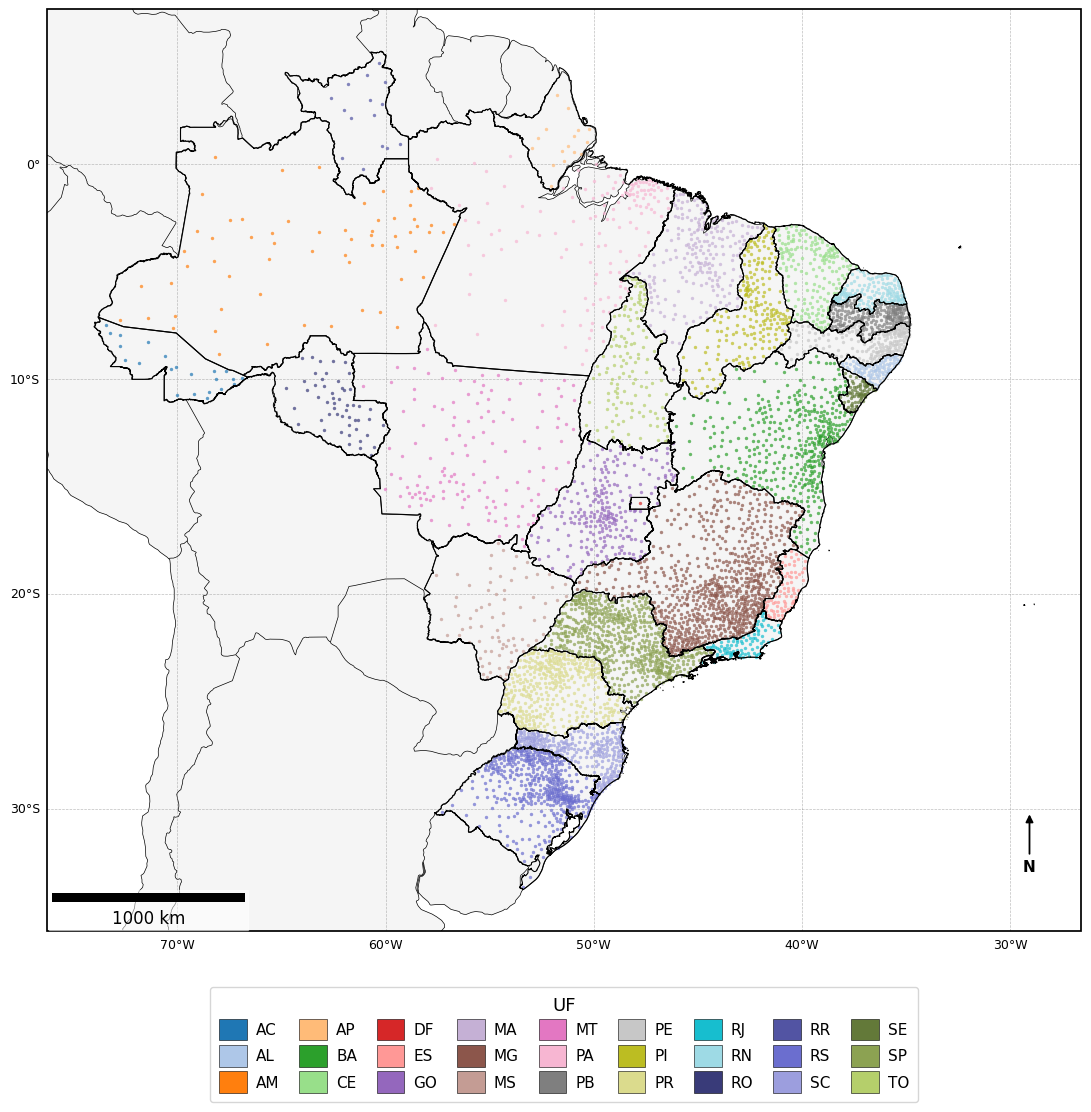

In [8]:
# Colorido por estado
warnings.filterwarnings("ignore")
centroide = plot_centroides(gdf,"titulo",
                 colorir_por_estado=True, savepath='centroides_uf.png')
centroide


# Capítulo 2 — Classificação climática principal
___

## 1.1 Köppen-Geiger (1936)

In [27]:
dados_koppen = {
    'Aw':  {'n_municipios': 2120, 'pct_municipios': 38.06, 'area_km2': 3730547, 'pct_area': 43.41},
    'Cfa': {'n_municipios': 996,  'pct_municipios': 17.88, 'area_km2': 465084,  'pct_area': 5.41},
    'Cwa': {'n_municipios': 558,  'pct_municipios': 10.02, 'area_km2': 233270,  'pct_area': 2.71},
    'As':  {'n_municipios': 546,  'pct_municipios': 9.80,  'area_km2': 191034,  'pct_area': 2.22},
    'BSh': {'n_municipios': 468,  'pct_municipios': 8.40,  'area_km2': 517186,  'pct_area': 6.02},
    'Cfb': {'n_municipios': 279,  'pct_municipios': 5.01,  'area_km2': 161800,  'pct_area': 1.88},
    'Am':  {'n_municipios': 261,  'pct_municipios': 4.69,  'area_km2': 1692644, 'pct_area': 19.70},
    'Cwb': {'n_municipios': 181,  'pct_municipios': 3.25,  'area_km2': 69156,   'pct_area': 0.80},
    'Af':  {'n_municipios': 147,  'pct_municipios': 2.64,  'area_km2': 1513885, 'pct_area': 17.62},
    'BWh': {'n_municipios': 6,    'pct_municipios': 0.11,  'area_km2': 15989,   'pct_area': 0.19},
    'Csb': {'n_municipios': 4,    'pct_municipios': 0.07,  'area_km2': 1679,    'pct_area': 0.02},
    'Csa': {'n_municipios': 4,    'pct_municipios': 0.07,  'area_km2': 963,     'pct_area': 0.01},
}

In [28]:
def _base_map(ax, titulo, anchor='S'):
    minx, miny, maxx, maxy = municipios_gdf.total_bounds
    dx = (maxx - minx) * 0.05; dy = (maxy - miny) * 0.05
    ax.set_extent([minx - dx, maxx + dx, miny - dy, maxy + dy], crs=ccrs.PlateCarree())
    ax.set_anchor(anchor)   # 'S' (funções antigas) ou 'N' (topo alinhado, esta função)
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    return minx, miny, maxx, maxy

In [29]:
def plot_categorico_com_heatmap(gdf_, coluna_codigo, labels, colors, titulo, legenda_titulo,
                                 dados_dict, nomes=None, savepath=None,
                                 legend_fontsize=12, legend_title_fontsize=13, ncol_legend=4,
                                 heatmap_cols=('n_municipios', 'pct_municipios', 'area_km2', 'pct_area'),
                                 heatmap_col_labels=('Municípios (nº)', 'Municípios (%)',
                                                      'Área (km²)', 'Área (%)'),
                                 heatmap_cmap='Blues', figsize=(16, 11)):
    """
    Mapa categórico com legenda tradicional abaixo do mapa (4 colunas, sem percentuais) +
    heatmap de estatísticas (dados_dict) ao lado, com topos alinhados.
    """
    classes = sorted(gdf_[coluna_codigo].dropna().unique().astype(int))
    n_classes = len(classes)
    n_linhas_legenda = math.ceil(n_classes / ncol_legend)

    # --------- Layout manual (frações da figura) ---------
    top, bottom_fig = 0.95, 0.05
    row_h, title_h, pad, gap = 0.032, 0.05, 0.02, 0.03
    legend_h = title_h + n_linhas_legenda * row_h + pad
    map_bottom = bottom_fig + legend_h + gap        # base do eixo do mapa (acima da legenda)

    left, map_w, hgap, heat_w = 0.03, 0.50, 0.06, 0.38

    fig = plt.figure(figsize=figsize)

    # ---------------- Mapa (topo em `top`, base em `map_bottom`) ----------------
    ax_map = plt.axes([left, map_bottom, map_w, top - map_bottom], projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax_map, titulo, anchor='N')
    for c in classes:
        gdf_[gdf_[coluna_codigo] == c].plot(ax=ax_map, color=colors[c], edgecolor='none',
                                             transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax_map, minx, miny, maxx, maxy)
    ax_map.set_title(titulo, fontsize=14, fontweight='bold', pad=10)

    if nomes:
        labs = [f'{labels[c]} — {nomes[c]}' for c in classes]
    else:
        labs = [f'{labels[c]}' for c in classes]
    patches = [mpatches.Patch(facecolor=colors[c], edgecolor='black', linewidth=0.4, label=l)
               for c, l in zip(classes, labs)]

    fig.legend(handles=patches, title=legenda_titulo, loc='upper center',
               bbox_to_anchor=(left + map_w / 2, map_bottom - gap),
               ncol=min(ncol_legend, n_classes),
               frameon=True, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize,
               handlelength=1.8, columnspacing=1.5, handletextpad=0.7,
               borderpad=0.6, labelspacing=0.5)

    # ---------------- Heatmap (mesmo topo `top`, base em `bottom_fig`) ----------------
    ax_heat = plt.axes([left + map_w + hgap, bottom_fig, heat_w, top - bottom_fig])

    ordem_labels = [labels[c] for c in classes]
    df_dados = pd.DataFrame(dados_dict).T.reindex(ordem_labels)
    df_plot = df_dados[list(heatmap_cols)].astype(float)

    df_norm = df_plot.copy()
    for col in df_norm.columns:
        cmin, cmax = df_norm[col].min(), df_norm[col].max()
        df_norm[col] = (df_norm[col] - cmin) / (cmax - cmin) if cmax > cmin else 0.5

    annot = pd.DataFrame(index=df_plot.index, columns=df_plot.columns, dtype=object)
    for col in df_plot.columns:
        if col in ('n_municipios', 'area_km2'):
            annot[col] = df_plot[col].apply(lambda x: f'{int(x):,}'.replace(',', '.'))
        else:  # pct_municipios, pct_area
            annot[col] = df_plot[col].apply(lambda x: f'{x:.2f}'.replace('.', ',') + '%')

    sns.heatmap(df_norm, annot=annot.values, fmt='', cmap=heatmap_cmap, cbar=False,
                linewidths=0.6, linecolor='white', ax=ax_heat,
                xticklabels=list(heatmap_col_labels), yticklabels=ordem_labels,
                annot_kws={'fontsize': 16})
    ax_heat.set_title('Estatísticas por classe climática', fontsize=13, fontweight='bold', pad=10)
    ax_heat.tick_params(axis='x', rotation=25, labelsize=16)
    ax_heat.tick_params(axis='y', rotation=0, labelsize=16)

    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

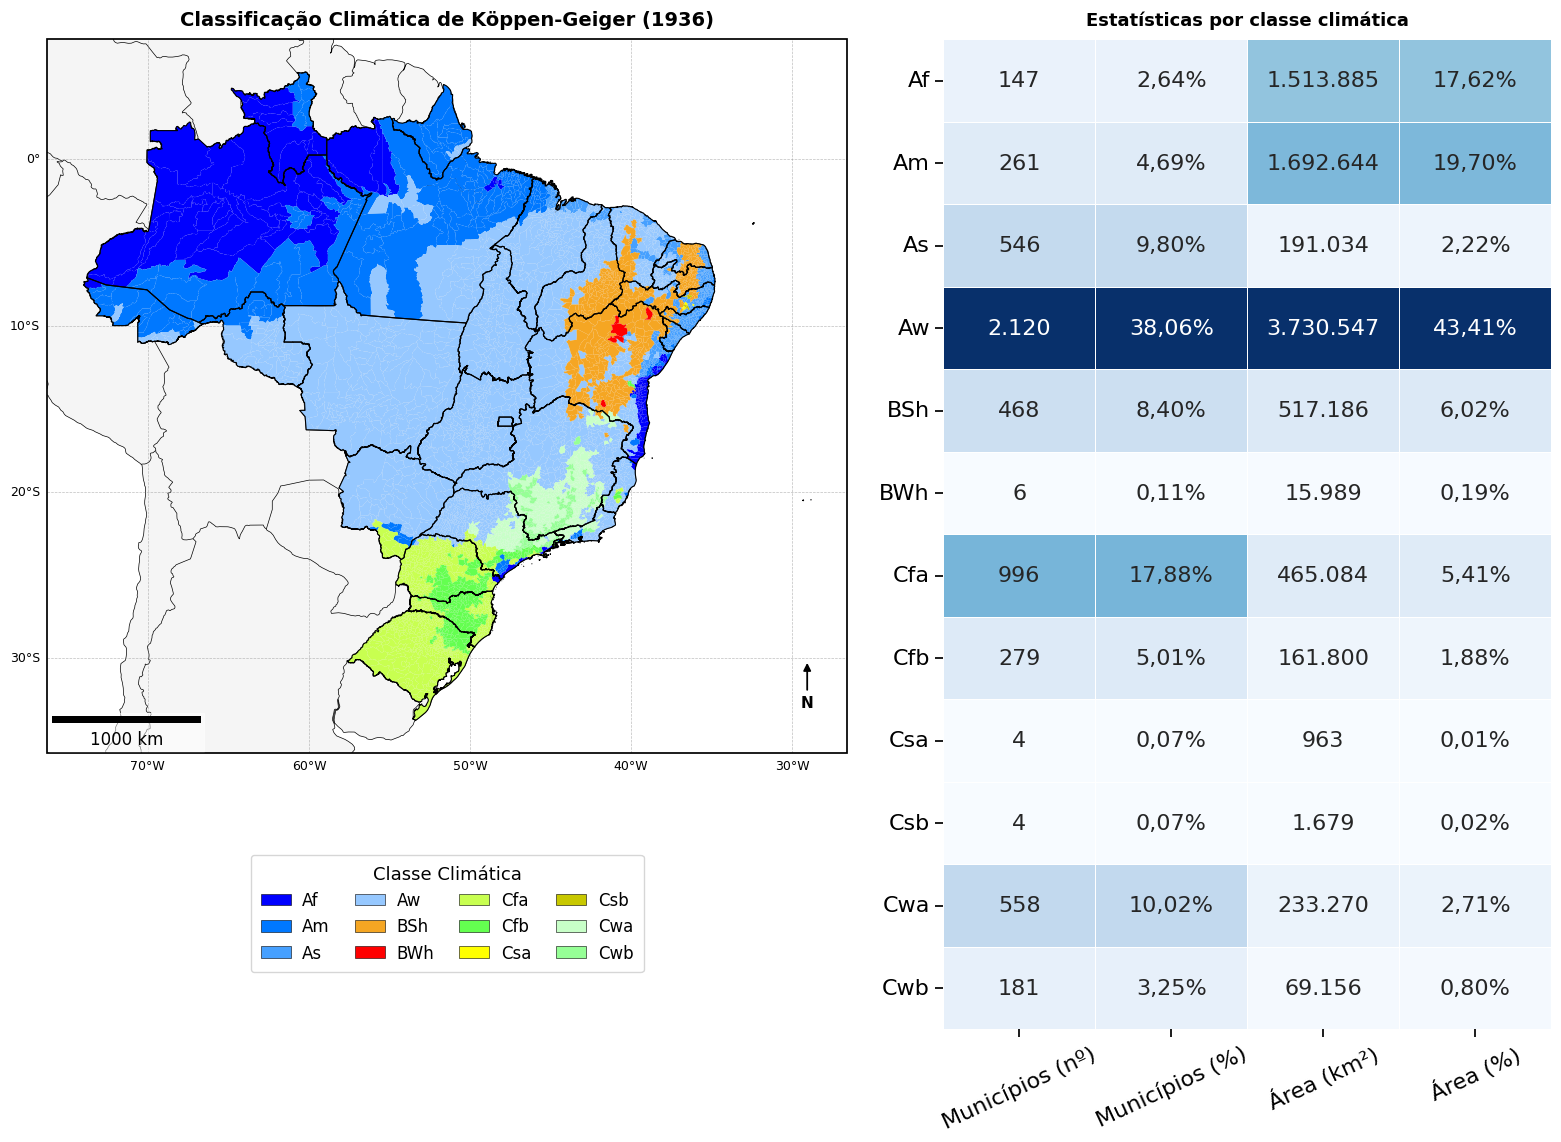

In [30]:
plot_categorico_com_heatmap(
    gdf_=gdf,
    coluna_codigo='classe_koppen_codigo',
    labels=KOPPEN_LABELS,
    colors=KOPPEN_COLORS,
    titulo='Classificação Climática de Köppen-Geiger (1936)',
    legenda_titulo='Classe Climática',
    dados_dict=dados_koppen,
    savepath='mapa_koppen_heatmap.png'
)

### 1.1.1 Multiplot - Köppen-Geiger (1936)

In [31]:
def plot_multiplot_variaveis_koppen(gdf_, savepath=None):
    """Painel 2x2 (linhas 1 e 2) + 1 centralizado na linha 3 — variáveis contínuas
    usadas na classificação de Köppen-Geiger. Segue o padrão _base_map + _decoracoes,
    com colorbar individual ao lado de cada mapa."""

    vars_continuas = [
        ('precip_anual_mm',          'Precipitação Anual',              'mm',  'YlGnBu'),
        ('precip_mes_mais_seco_mm',  'Precipitação do Mês mais Seco',   'mm',  'YlGnBu'),
        ('temp_anual_c',             'Temperatura Média Anual',         '°C',  'RdYlBu_r'),
        ('temp_mes_mais_frio_c',     'Temperatura do Mês mais Frio',    '°C',  'RdYlBu_r'),
        ('temp_mes_mais_quente_c',   'Temperatura do Mês mais Quente',  '°C',  'RdYlBu_r'),
    ]

    faltando = [col for col, *_ in vars_continuas if col not in gdf_.columns]
    if faltando:
        raise ValueError(f'Colunas ausentes no gdf_ passado: {faltando}')

    fig = plt.figure(figsize=(14, 16))
    gs = fig.add_gridspec(3, 4, hspace=0.30, wspace=0.30)

    posicoes = [
        gs[0, 0:2], gs[0, 2:4],
        gs[1, 0:2], gs[1, 2:4],
        gs[2, 1:3],
    ]

    for (col, titulo, unidade, cmap), pos_gs in zip(vars_continuas, posicoes):
        ax = fig.add_subplot(pos_gs, projection=ccrs.PlateCarree())
        minx, miny, maxx, maxy = _base_map(ax, titulo)

        vmin, vmax = gdf_[col].min(), gdf_[col].max()
        gdf_.plot(ax=ax, column=col, cmap=cmap, vmin=vmin, vmax=vmax,
                  edgecolor='none', transform=ccrs.PlateCarree(), zorder=3)

        _decoracoes(ax, minx, miny, maxx, maxy)
        ax.set_title(titulo, fontsize=12, fontweight='bold', pad=8)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
        cb = plt.colorbar(sm, ax=ax, shrink=0.75, pad=0.03, fraction=0.05)
        cb.set_label(unidade, fontsize=9)
        cb.ax.tick_params(labelsize=8)

    fig.suptitle('Variáveis Climáticas — Classificação de Köppen-Geiger',
                 fontsize=16, fontweight='bold', y=0.93)

    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

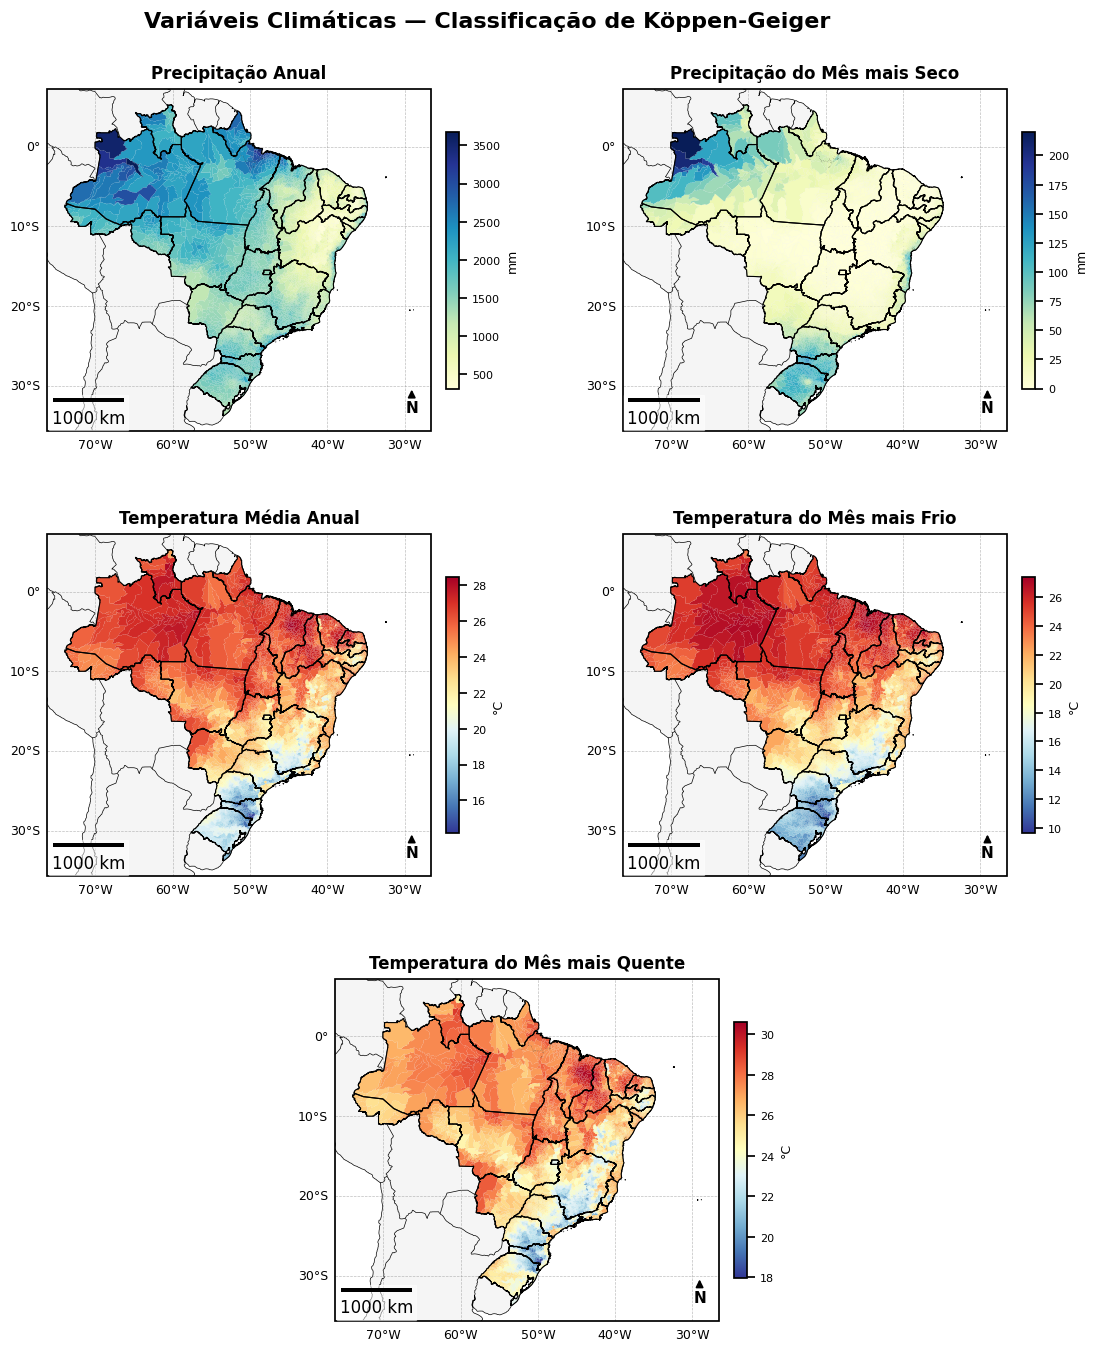

In [32]:
warnings.filterwarnings("ignore")
plot_multiplot_variaveis_koppen(gdf, savepath='multiplot_koppen_variaveis.png')

## 1.2 Camargo (1991) mod. Maluf (2000)

In [15]:
dados_camargo = {
    'TR-MOi':  {'n_municipios': 1315, 'pct_municipios': 23.61, 'area_km2': 3189222.0, 'pct_area': 37.11},
    'ST-MOi':  {'n_municipios': 938,  'pct_municipios': 16.84, 'area_km2': 425057.0,  'pct_area': 4.95},
    'TR-SEp':  {'n_municipios': 701,  'pct_municipios': 12.59, 'area_km2': 444109.0,  'pct_area': 5.17},
    'ST-UMp':  {'n_municipios': 461,  'pct_municipios': 8.28,  'area_km2': 138503.0,  'pct_area': 1.61},
    'TR-SEi':  {'n_municipios': 406,  'pct_municipios': 7.29,  'area_km2': 671735.0,  'pct_area': 7.82},
    'TR-MOp':  {'n_municipios': 391,  'pct_municipios': 7.02,  'area_km2': 542716.0,  'pct_area': 6.32},
    'TE-UMp':  {'n_municipios': 221,  'pct_municipios': 3.97,  'area_km2': 115019.0,  'pct_area': 1.34},
    'ST-UMv':  {'n_municipios': 202,  'pct_municipios': 3.63,  'area_km2': 73966.0,   'pct_area': 0.86},
    'ST-UMi':  {'n_municipios': 165,  'pct_municipios': 2.96,  'area_km2': 81365.0,   'pct_area': 0.95},
    'TR-MOv':  {'n_municipios': 155,  'pct_municipios': 2.78,  'area_km2': 180795.0,  'pct_area': 2.10},
    'TR-UMi':  {'n_municipios': 125,  'pct_municipios': 2.24,  'area_km2': 1619586.0, 'pct_area': 18.85},
    'TR-SEv':  {'n_municipios': 118,  'pct_municipios': 2.12,  'area_km2': 52865.0,   'pct_area': 0.62},
    'ST-SEi':  {'n_municipios': 76,   'pct_municipios': 1.36,  'area_km2': 92009.0,   'pct_area': 1.07},
    'ST-SEp':  {'n_municipios': 75,   'pct_municipios': 1.35,  'area_km2': 34418.0,   'pct_area': 0.40},
    'TE-UMi':  {'n_municipios': 54,   'pct_municipios': 0.97,  'area_km2': 29300.0,   'pct_area': 0.34},
    'ST-MOv':  {'n_municipios': 46,   'pct_municipios': 0.83,  'area_km2': 82477.0,   'pct_area': 0.96},
    'ST-MOp':  {'n_municipios': 30,   'pct_municipios': 0.54,  'area_km2': 13514.0,   'pct_area': 0.16},
    'TR-UMp':  {'n_municipios': 22,   'pct_municipios': 0.39,  'area_km2': 578986.0,  'pct_area': 6.74},
    'TR-UMv':  {'n_municipios': 22,   'pct_municipios': 0.39,  'area_km2': 179138.0,  'pct_area': 2.08},
    'ST-SEv':  {'n_municipios': 13,   'pct_municipios': 0.23,  'area_km2': 6303.0,    'pct_area': 0.07},
    'STE-MOv': {'n_municipios': 11,   'pct_municipios': 0.20,  'area_km2': 23473.0,   'pct_area': 0.27},
    'TE-MOi':  {'n_municipios': 11,   'pct_municipios': 0.20,  'area_km2': 3029.0,    'pct_area': 0.04},
    'TE-UMv':  {'n_municipios': 4,    'pct_municipios': 0.07,  'area_km2': 932.0,     'pct_area': 0.01},
    'STE-UMp': {'n_municipios': 4,    'pct_municipios': 0.07,  'area_km2': 2445.0,    'pct_area': 0.03},
    'STE-UMv': {'n_municipios': 2,    'pct_municipios': 0.04,  'area_km2': 6878.0,    'pct_area': 0.08},
    'TE-MOv':  {'n_municipios': 2,    'pct_municipios': 0.04,  'area_km2': 5398.0,    'pct_area': 0.06},
}

In [16]:
def _base_map(ax, titulo, anchor='S'):
    minx, miny, maxx, maxy = municipios_gdf.total_bounds
    dx = (maxx - minx) * 0.05; dy = (maxy - miny) * 0.05
    ax.set_extent([minx - dx, maxx + dx, miny - dy, maxy + dy], crs=ccrs.PlateCarree())
    ax.set_anchor(anchor)   # 'S' (funções antigas) ou 'N' (topo alinhado, novas funções)
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    return minx, miny, maxx, maxy

In [17]:
def plot_categorico_texto_com_heatmap(gdf_, coluna_texto, titulo, legenda_titulo,
                                       dados_dict, savepath=None,
                                       legend_fontsize=10, legend_title_fontsize=12, ncol_legend=5,
                                       heatmap_cols=('n_municipios', 'pct_municipios', 'area_km2', 'pct_area'),
                                       heatmap_col_labels=('Municípios (nº)', 'Municípios (%)',
                                                            'Área (km²)', 'Área (%)'),
                                       heatmap_cmap='Blues', figsize=(18, 13)):
    """
    Mapa categórico TEXTUAL (ex.: camargo_completo) com legenda tradicional abaixo do mapa
    (N colunas, sem percentuais) + heatmap de estatísticas (dados_dict) ao lado,
    topos alinhados. Segue o mesmo padrão de plot_categorico_com_heatmap (Köppen),
    adaptado para colunas de texto com muitas classes (usa _cores_texto).
    """
    dados = gdf_.dropna(subset=[coluna_texto])
    classes = dados[coluna_texto].value_counts().index.tolist()   # ordem por frequência
    n_classes = len(classes)
    n_linhas_legenda = math.ceil(n_classes / ncol_legend)
    cores = _cores_texto(classes)

    # --------- Layout manual (frações da figura) ---------
    top, bottom_fig = 0.95, 0.05
    row_h, title_h, pad, gap = 0.028, 0.045, 0.02, 0.03
    legend_h = title_h + n_linhas_legenda * row_h + pad
    map_bottom = bottom_fig + legend_h + gap

    left, map_w, hgap, heat_w = 0.03, 0.50, 0.06, 0.38

    fig = plt.figure(figsize=figsize)

    # ---------------- Mapa (topo em `top`, base em `map_bottom`) ----------------
    ax_map = plt.axes([left, map_bottom, map_w, top - map_bottom], projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax_map, titulo, anchor='N')
    for cls in classes:
        dados[dados[coluna_texto] == cls].plot(ax=ax_map, color=cores[cls], edgecolor='none',
                                                transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax_map, minx, miny, maxx, maxy)
    ax_map.set_title(titulo, fontsize=14, fontweight='bold', pad=10)

    patches = [mpatches.Patch(facecolor=cores[cls], edgecolor='black', linewidth=0.4, label=cls)
               for cls in classes]

    fig.legend(handles=patches, title=legenda_titulo, loc='upper center',
               bbox_to_anchor=(left + map_w / 2, map_bottom - gap),
               ncol=min(ncol_legend, n_classes),
               frameon=True, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize,
               handlelength=1.4, columnspacing=1.5, handletextpad=0.7,
               borderpad=0.6, labelspacing=0.5)

    # ---------------- Heatmap (mesmo topo `top`, base em `bottom_fig`) ----------------
    ax_heat = plt.axes([left + map_w + hgap, bottom_fig, heat_w, top - bottom_fig])

    df_dados = pd.DataFrame(dados_dict).T.reindex(classes)
    df_plot = df_dados[list(heatmap_cols)].astype(float)

    df_norm = df_plot.copy()
    for col in df_norm.columns:
        cmin, cmax = df_norm[col].min(), df_norm[col].max()
        df_norm[col] = (df_norm[col] - cmin) / (cmax - cmin) if cmax > cmin else 0.5

    annot = pd.DataFrame(index=df_plot.index, columns=df_plot.columns, dtype=object)
    for col in df_plot.columns:
        if col in ('n_municipios', 'area_km2'):
            annot[col] = df_plot[col].apply(lambda x: f'{int(x):,}'.replace(',', '.'))
        else:  # pct_municipios, pct_area
            annot[col] = df_plot[col].apply(lambda x: f'{x:.2f}'.replace('.', ',') + '%')

    sns.heatmap(df_norm, annot=annot.values, fmt='', cmap=heatmap_cmap, cbar=False,
                linewidths=0.6, linecolor='white', ax=ax_heat,
                xticklabels=list(heatmap_col_labels), yticklabels=classes,
                annot_kws={'fontsize': 16})
    ax_heat.set_title('Estatísticas por classe climática', fontsize=13, fontweight='bold', pad=10)
    ax_heat.tick_params(axis='x', rotation=25, labelsize=16)
    ax_heat.tick_params(axis='y', rotation=0, labelsize=16)

    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

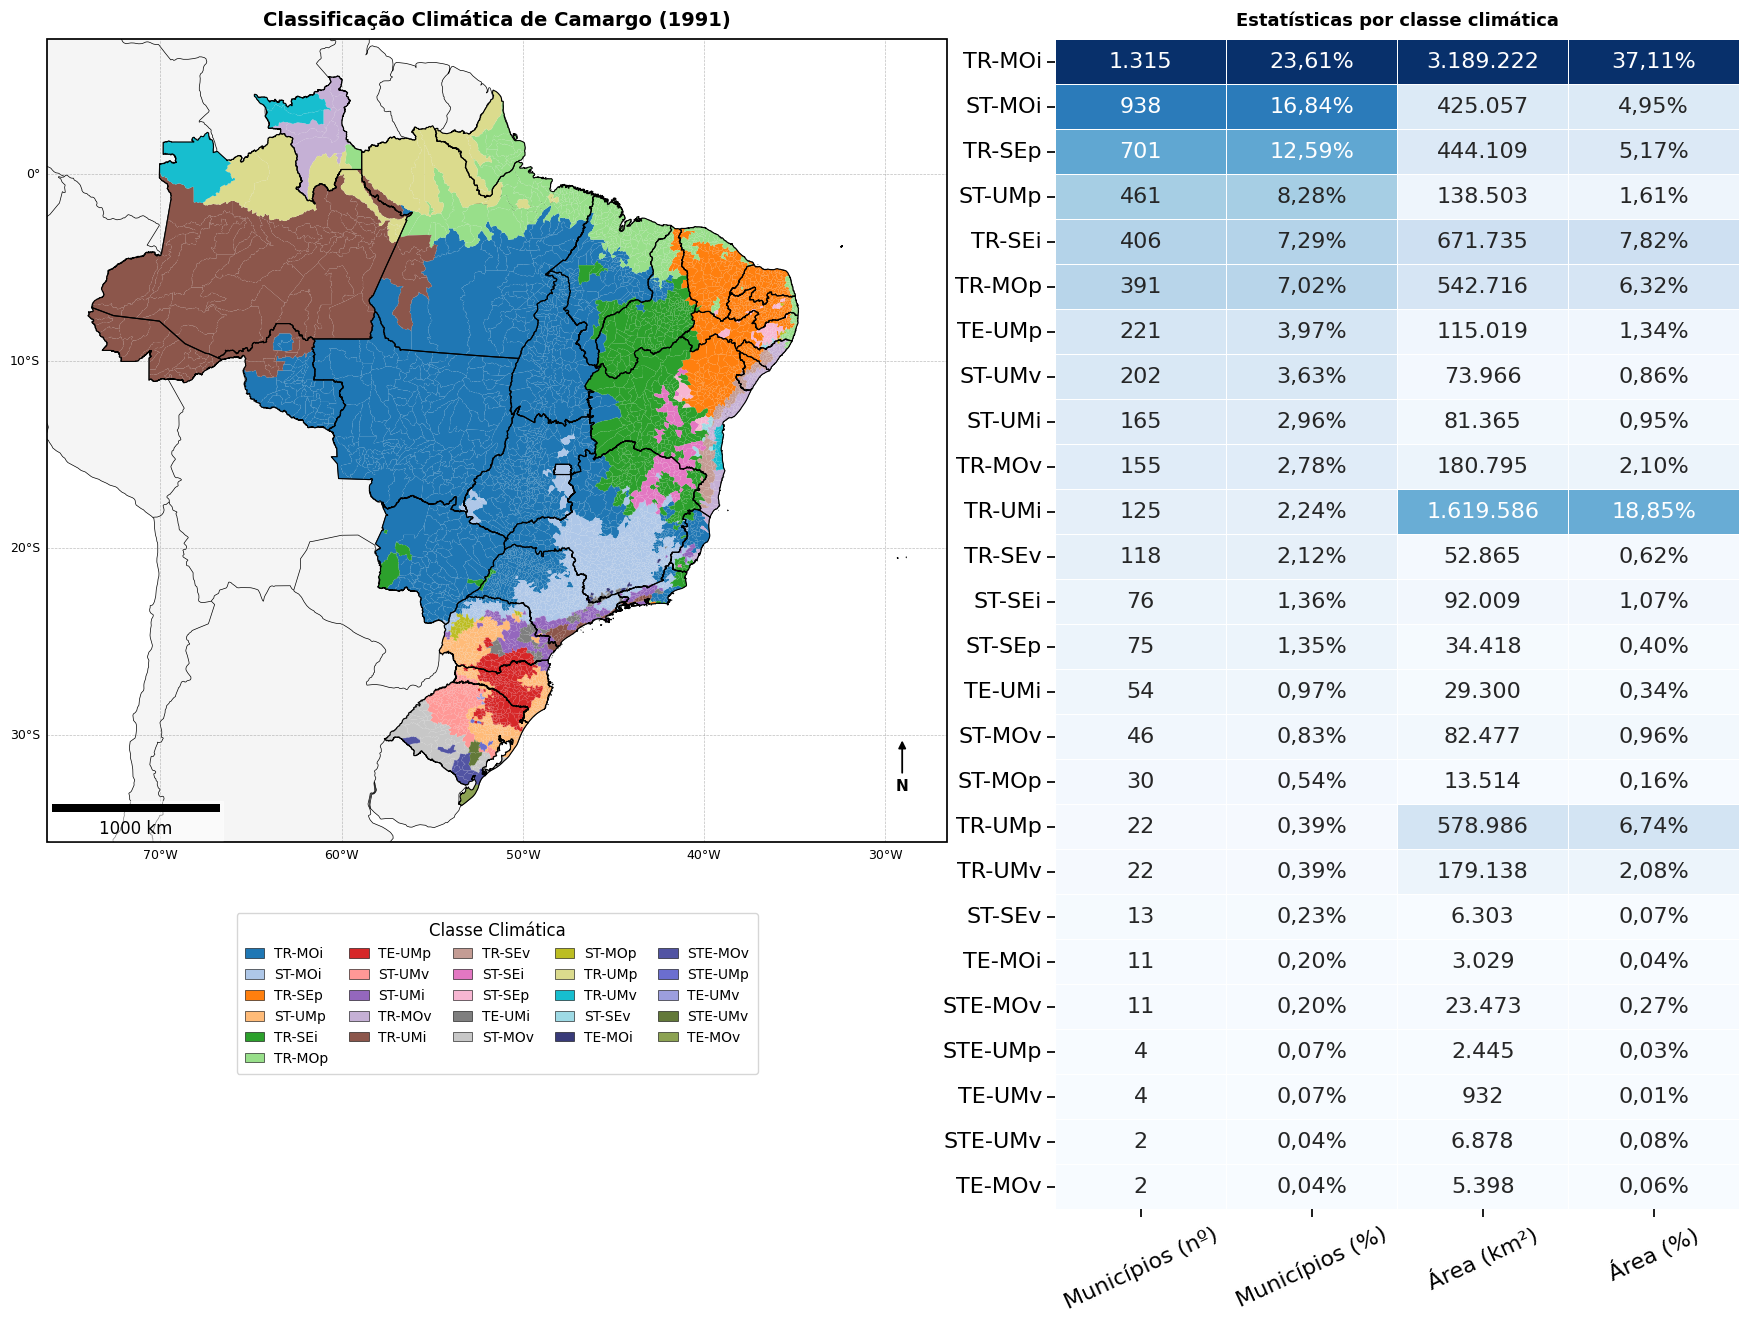

In [18]:
plot_categorico_texto_com_heatmap(
    gdf_=gdf,
    coluna_texto='camargo_completo',
    titulo='Classificação Climática de Camargo (1991)',
    legenda_titulo='Classe Climática',
    dados_dict=dados_camargo,
    savepath='mapa_camargo_heatmap.png'
)

### 1.2.1 Multiplot -  Camargo (1991) mod. Maluf (2000)

In [19]:
def plot_multiplot_camargo_misto(gdf_, savepath=None):
    """Painel 2x2: cm_termico_codigo e cm_hidrico_codigo (categóricos, com legenda de
    patches) + def_anual_mm e temp_anual_c (contínuos, com colorbar). Segue o padrão
    _base_map + _decoracoes."""

    fig = plt.figure(figsize=(16, 13))
    gs = fig.add_gridspec(2, 2, hspace=0.28, wspace=0.15)

    # ---- (0,0) cm_termico_codigo — categórico ----
    ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
    patches1 = _plot_mapa_numerico(ax1, gdf_, 'cm_termico_codigo',
                                    CM_TERMICO_LABELS, CM_TERMICO_COLORS,
                                    'Classe Térmica', nomes=CM_TERMICO_NOMES,
                                    titulo_fontsize=12)
    ax1.legend(handles=patches1, loc='upper center', bbox_to_anchor=(0.5, -0.05),
               ncol=2, frameon=True, fontsize=7, title='Classe Térmica', title_fontsize=8,
               handlelength=1.0, columnspacing=0.9, handletextpad=0.5, borderpad=0.4,
               labelspacing=0.3)

    # ---- (0,1) cm_hidrico_codigo — categórico ----
    ax2 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
    patches2 = _plot_mapa_numerico(ax2, gdf_, 'cm_hidrico_codigo',
                                    CM_HIDRICO_LABELS, CM_HIDRICO_COLORS,
                                    'Classe Hídrica', nomes=CM_HIDRICO_NOMES,
                                    titulo_fontsize=12)
    ax2.legend(handles=patches2, loc='upper center', bbox_to_anchor=(0.5, -0.05),
               ncol=2, frameon=True, fontsize=7, title='Classe Hídrica', title_fontsize=8,
               handlelength=1.0, columnspacing=0.9, handletextpad=0.5, borderpad=0.4,
               labelspacing=0.3)

    # ---- (1,0) def_anual_mm — contínuo ----
    ax3 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax3, 'Deficiência Hídrica Anual')
    vmin, vmax = gdf_['def_anual_mm'].min(), gdf_['def_anual_mm'].max()
    gdf_.plot(ax=ax3, column='def_anual_mm', cmap='YlOrRd', vmin=vmin, vmax=vmax,
              edgecolor='none', transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax3, minx, miny, maxx, maxy)
    ax3.set_title('Deficiência Hídrica Anual', fontsize=12, fontweight='bold', pad=8)
    sm3 = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cb3 = plt.colorbar(sm3, ax=ax3, shrink=0.75, pad=0.03, fraction=0.05)
    cb3.set_label('mm', fontsize=9)
    cb3.ax.tick_params(labelsize=8)

    # ---- (1,1) temp_anual_c — contínuo ----
    ax4 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax4, 'Temperatura Média Anual')
    vmin, vmax = gdf_['temp_anual_c'].min(), gdf_['temp_anual_c'].max()
    gdf_.plot(ax=ax4, column='temp_anual_c', cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
              edgecolor='none', transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax4, minx, miny, maxx, maxy)
    ax4.set_title('Temperatura Média Anual', fontsize=12, fontweight='bold', pad=8)
    sm4 = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=plt.Normalize(vmin=vmin, vmax=vmax))
    cb4 = plt.colorbar(sm4, ax=ax4, shrink=0.75, pad=0.03, fraction=0.05)
    cb4.set_label('°C', fontsize=9)
    cb4.ax.tick_params(labelsize=8)

    fig.suptitle('Classificação de Camargo — Classes e Variáveis-Base',
                 fontsize=16, fontweight='bold', y=0.93)

    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

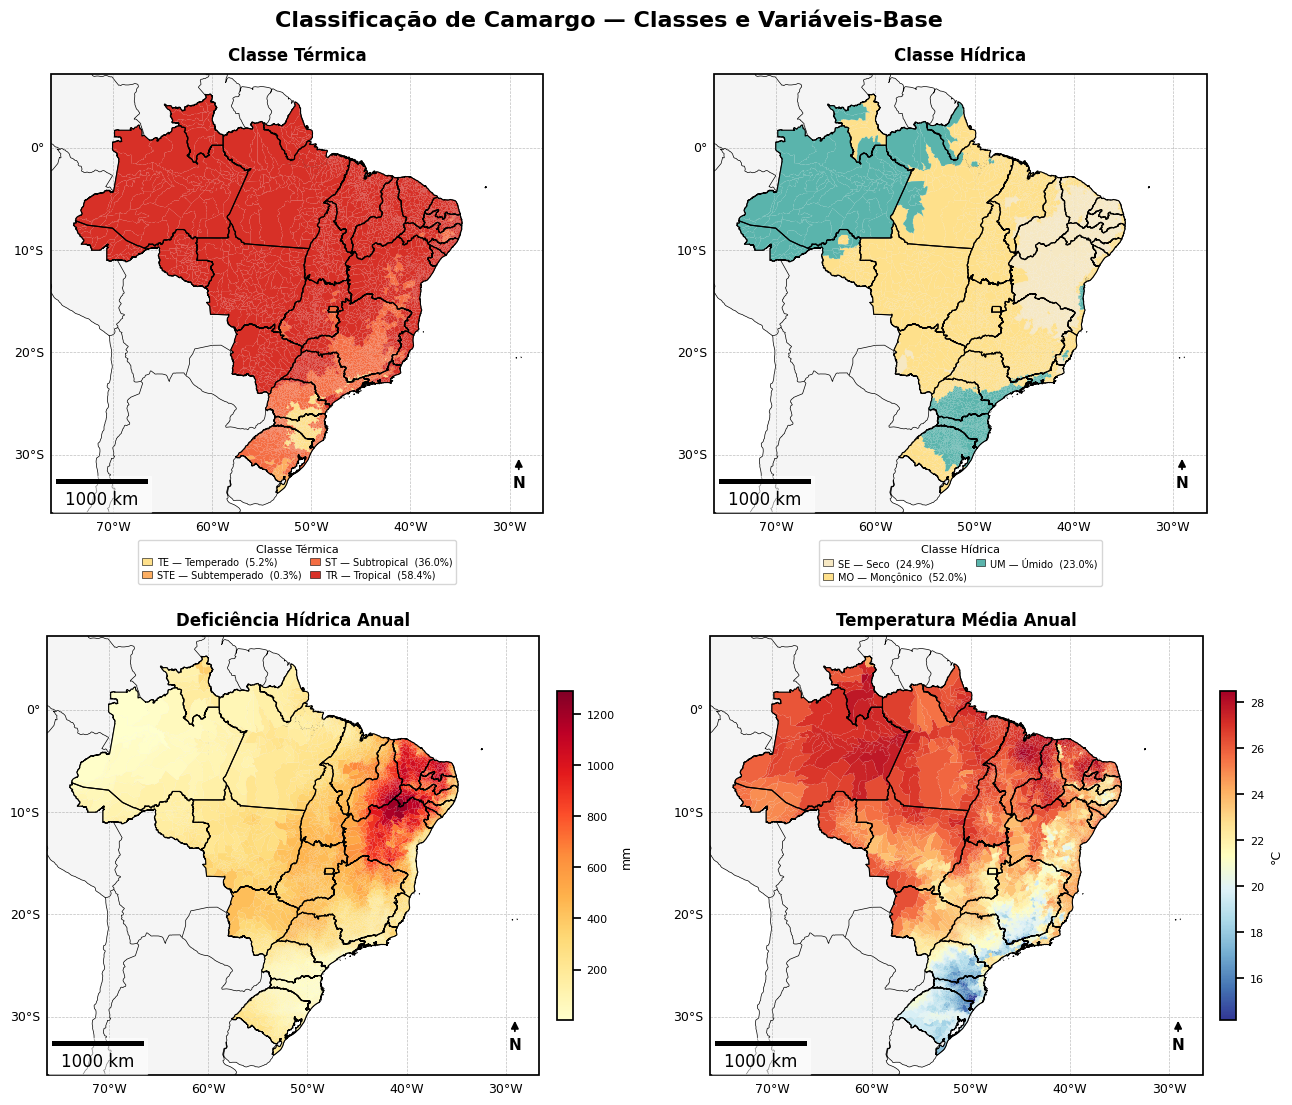

In [20]:
warnings.filterwarnings("ignore")
plot_multiplot_camargo_misto(gdf, savepath='multiplot_camargo_misto.png')

## 1.3 Thornthwaite (1948)

In [21]:
dados_thornthwaite = {
    "DdA'b3'": {'n_municipios': 450, 'pct_municipios': 8.08, 'area_km2': 399954.0, 'pct_area': 4.65},
    "C2wA'b2'": {'n_municipios': 375, 'pct_municipios': 6.73, 'area_km2': 216900.0, 'pct_area': 2.52},
    "DdA'b2'": {'n_municipios': 375, 'pct_municipios': 6.73, 'area_km2': 257176.0, 'pct_area': 2.99},
    "B1wA'b4'": {'n_municipios': 255, 'pct_municipios': 4.58, 'area_km2': 395539.0, 'pct_area': 4.6},
    "B1wA'b3'": {'n_municipios': 199, 'pct_municipios': 3.57, 'area_km2': 172824.0, 'pct_area': 2.01},
    "B1wB4'b2'": {'n_municipios': 197, 'pct_municipios': 3.54, 'area_km2': 63101.0, 'pct_area': 0.73},
    "B3rB4'b1'": {'n_municipios': 173, 'pct_municipios': 3.11, 'area_km2': 66726.0, 'pct_area': 0.78},
    "B2rB4'b1'": {'n_municipios': 153, 'pct_municipios': 2.75, 'area_km2': 55993.0, 'pct_area': 0.65},
    "B2rA'b1'": {'n_municipios': 141, 'pct_municipios': 2.53, 'area_km2': 63542.0, 'pct_area': 0.74},
    "B3rA'b1'": {'n_municipios': 137, 'pct_municipios': 2.46, 'area_km2': 29074.0, 'pct_area': 0.34},
    "C1dA'b2'": {'n_municipios': 134, 'pct_municipios': 2.41, 'area_km2': 88915.0, 'pct_area': 1.03},
    "C2wA'b3'": {'n_municipios': 131, 'pct_municipios': 2.35, 'area_km2': 273025.0, 'pct_area': 3.18},
    "B2wB4'b2'": {'n_municipios': 111, 'pct_municipios': 1.99, 'area_km2': 34201.0, 'pct_area': 0.4},
    "C2w2A'b3'": {'n_municipios': 110, 'pct_municipios': 1.97, 'area_km2': 61902.0, 'pct_area': 0.72},
    "C2wA'b4'": {'n_municipios': 108, 'pct_municipios': 1.94, 'area_km2': 157282.0, 'pct_area': 1.83},
    "B1wA'a'": {'n_municipios': 105, 'pct_municipios': 1.89, 'area_km2': 276873.0, 'pct_area': 3.22},
    "B3rB3'b1'": {'n_municipios': 104, 'pct_municipios': 1.87, 'area_km2': 55635.0, 'pct_area': 0.65},
    "C1sA'b3'": {'n_municipios': 102, 'pct_municipios': 1.83, 'area_km2': 182931.0, 'pct_area': 2.13},
    "C2sA'b2'": {'n_municipios': 99, 'pct_municipios': 1.78, 'area_km2': 39184.0, 'pct_area': 0.46},
    "B2wA'b3'": {'n_municipios': 98, 'pct_municipios': 1.76, 'area_km2': 63074.0, 'pct_area': 0.73},
    "C1sA'b2'": {'n_municipios': 96, 'pct_municipios': 1.72, 'area_km2': 88589.0, 'pct_area': 1.03},
    "C1wA'b2'": {'n_municipios': 82, 'pct_municipios': 1.47, 'area_km2': 19045.0, 'pct_area': 0.22},
    "B1rA'b2'": {'n_municipios': 81, 'pct_municipios': 1.45, 'area_km2': 45967.0, 'pct_area': 0.53},
    "B2rB4'b2'": {'n_municipios': 75, 'pct_municipios': 1.35, 'area_km2': 27167.0, 'pct_area': 0.32},
    "C1sA'b4'": {'n_municipios': 75, 'pct_municipios': 1.35, 'area_km2': 112336.0, 'pct_area': 1.31},
    "B1rB4'b2'": {'n_municipios': 73, 'pct_municipios': 1.31, 'area_km2': 38949.0, 'pct_area': 0.45},
    "B2wA'a'": {'n_municipios': 70, 'pct_municipios': 1.26, 'area_km2': 378691.0, 'pct_area': 4.41},
    "DdA'b4'": {'n_municipios': 61, 'pct_municipios': 1.1, 'area_km2': 93126.0, 'pct_area': 1.08},
    "B1rA'b1'": {'n_municipios': 60, 'pct_municipios': 1.08, 'area_km2': 33413.0, 'pct_area': 0.39},
    "B4rB3'b1'": {'n_municipios': 59, 'pct_municipios': 1.06, 'area_km2': 26804.0, 'pct_area': 0.31},
    "B1rB4'b1'": {'n_municipios': 56, 'pct_municipios': 1.01, 'area_km2': 21956.0, 'pct_area': 0.26},
    "C2w2A'b4'": {'n_municipios': 54, 'pct_municipios': 0.97, 'area_km2': 105842.0, 'pct_area': 1.23},
    "B1sA'b2'": {'n_municipios': 47, 'pct_municipios': 0.84, 'area_km2': 11979.0, 'pct_area': 0.14},
    "B2wA'b4'": {'n_municipios': 47, 'pct_municipios': 0.84, 'area_km2': 161350.0, 'pct_area': 1.88},
    "B3wA'a'": {'n_municipios': 44, 'pct_municipios': 0.79, 'area_km2': 405792.0, 'pct_area': 4.72},
    "ArA'b4'": {'n_municipios': 42, 'pct_municipios': 0.75, 'area_km2': 296425.0, 'pct_area': 3.45},
    "C2rA'b2'": {'n_municipios': 40, 'pct_municipios': 0.72, 'area_km2': 30416.0, 'pct_area': 0.35},
    "B1wA'b2'": {'n_municipios': 37, 'pct_municipios': 0.66, 'area_km2': 14654.0, 'pct_area': 0.17},
    "C2wA'a'": {'n_municipios': 37, 'pct_municipios': 0.66, 'area_km2': 67766.0, 'pct_area': 0.79},
    "B4rA'b4'": {'n_municipios': 35, 'pct_municipios': 0.63, 'area_km2': 254535.0, 'pct_area': 2.96},
    "B1rB4'c2'": {'n_municipios': 34, 'pct_municipios': 0.61, 'area_km2': 21356.0, 'pct_area': 0.25},
    "EdA'b2'": {'n_municipios': 33, 'pct_municipios': 0.59, 'area_km2': 54722.0, 'pct_area': 0.64},
    "B1w2A'b4'": {'n_municipios': 33, 'pct_municipios': 0.59, 'area_km2': 56565.0, 'pct_area': 0.66},
    "C1dA'b3'": {'n_municipios': 32, 'pct_municipios': 0.57, 'area_km2': 36946.0, 'pct_area': 0.43},
    "C2wB4'b2'": {'n_municipios': 31, 'pct_municipios': 0.56, 'area_km2': 12883.0, 'pct_area': 0.15},
    "EdA'b3'": {'n_municipios': 28, 'pct_municipios': 0.5, 'area_km2': 63028.0, 'pct_area': 0.73},
    "DsA'b3'": {'n_municipios': 28, 'pct_municipios': 0.5, 'area_km2': 15624.0, 'pct_area': 0.18},
    "B3rB4'b2'": {'n_municipios': 27, 'pct_municipios': 0.48, 'area_km2': 7947.0, 'pct_area': 0.09},
    "C1dA'b4'": {'n_municipios': 26, 'pct_municipios': 0.47, 'area_km2': 88095.0, 'pct_area': 1.03},
    "ArA'a'": {'n_municipios': 25, 'pct_municipios': 0.45, 'area_km2': 371235.0, 'pct_area': 4.32},
    "C1s2A'b4'": {'n_municipios': 24, 'pct_municipios': 0.43, 'area_km2': 23402.0, 'pct_area': 0.27},
    "ArB4'a'": {'n_municipios': 22, 'pct_municipios': 0.39, 'area_km2': 592749.0, 'pct_area': 6.9},
    "B1rA'c2'": {'n_municipios': 20, 'pct_municipios': 0.36, 'area_km2': 30461.0, 'pct_area': 0.35},
    "B4rB4'b1'": {'n_municipios': 20, 'pct_municipios': 0.36, 'area_km2': 8004.0, 'pct_area': 0.09},
    "B4rA'a'": {'n_municipios': 19, 'pct_municipios': 0.34, 'area_km2': 197534.0, 'pct_area': 2.3},
    "B3rA'b4'": {'n_municipios': 19, 'pct_municipios': 0.34, 'area_km2': 357207.0, 'pct_area': 4.16},
    "B2rB3'b1'": {'n_municipios': 18, 'pct_municipios': 0.32, 'area_km2': 9690.0, 'pct_area': 0.11},
    "B3rB3'b2'": {'n_municipios': 18, 'pct_municipios': 0.32, 'area_km2': 4500.0, 'pct_area': 0.05},
    "B2wB4'b3'": {'n_municipios': 17, 'pct_municipios': 0.31, 'area_km2': 5976.0, 'pct_area': 0.07},
    "B2rA'b2'": {'n_municipios': 16, 'pct_municipios': 0.29, 'area_km2': 8835.0, 'pct_area': 0.1},
    "C1s2A'b3'": {'n_municipios': 16, 'pct_municipios': 0.29, 'area_km2': 8424.0, 'pct_area': 0.1},
    "C2rB4'b2'": {'n_municipios': 15, 'pct_municipios': 0.27, 'area_km2': 7536.0, 'pct_area': 0.09},
    "B2rB3'b2'": {'n_municipios': 15, 'pct_municipios': 0.27, 'area_km2': 4215.0, 'pct_area': 0.05},
    "ArB3'b2'": {'n_municipios': 15, 'pct_municipios': 0.27, 'area_km2': 4254.0, 'pct_area': 0.05},
    "ArB4'b4'": {'n_municipios': 15, 'pct_municipios': 0.27, 'area_km2': 373779.0, 'pct_area': 4.35},
    "B4rB4'a'": {'n_municipios': 14, 'pct_municipios': 0.25, 'area_km2': 81701.0, 'pct_area': 0.95},
    "B2rB4'c2'": {'n_municipios': 13, 'pct_municipios': 0.23, 'area_km2': 10678.0, 'pct_area': 0.12},
    "B1sA'c2'": {'n_municipios': 13, 'pct_municipios': 0.23, 'area_km2': 43924.0, 'pct_area': 0.51},
    "B4rB3'b2'": {'n_municipios': 12, 'pct_municipios': 0.22, 'area_km2': 6131.0, 'pct_area': 0.07},
    "C2sA'b3'": {'n_municipios': 12, 'pct_municipios': 0.22, 'area_km2': 2502.0, 'pct_area': 0.03},
    "C2s2A'b2'": {'n_municipios': 11, 'pct_municipios': 0.2, 'area_km2': 1300.0, 'pct_area': 0.02},
    "B3rA'a'": {'n_municipios': 11, 'pct_municipios': 0.2, 'area_km2': 251287.0, 'pct_area': 2.92},
    "B4rB4'b4'": {'n_municipios': 9, 'pct_municipios': 0.16, 'area_km2': 114679.0, 'pct_area': 1.33},
    "B4rA'b1'": {'n_municipios': 9, 'pct_municipios': 0.16, 'area_km2': 1436.0, 'pct_area': 0.02},
    "AwA'b4'": {'n_municipios': 9, 'pct_municipios': 0.16, 'area_km2': 6498.0, 'pct_area': 0.08},
    "B4rB4'b2'": {'n_municipios': 8, 'pct_municipios': 0.14, 'area_km2': 3722.0, 'pct_area': 0.04},
    "B4wA'a'": {'n_municipios': 8, 'pct_municipios': 0.14, 'area_km2': 76779.0, 'pct_area': 0.89},
    "B2sA'b2'": {'n_municipios': 8, 'pct_municipios': 0.14, 'area_km2': 2590.0, 'pct_area': 0.03},
    "ArB3'b1'": {'n_municipios': 8, 'pct_municipios': 0.14, 'area_km2': 6084.0, 'pct_area': 0.07},
    "ArB4'b2'": {'n_municipios': 8, 'pct_municipios': 0.14, 'area_km2': 2753.0, 'pct_area': 0.03},
    "B3wA'b4'": {'n_municipios': 8, 'pct_municipios': 0.14, 'area_km2': 48135.0, 'pct_area': 0.56},
    "C1wA'b3'": {'n_municipios': 8, 'pct_municipios': 0.14, 'area_km2': 2229.0, 'pct_area': 0.03},
    "C1sA'a'": {'n_municipios': 8, 'pct_municipios': 0.14, 'area_km2': 41977.0, 'pct_area': 0.49},
    "B3rB4'b4'": {'n_municipios': 7, 'pct_municipios': 0.13, 'area_km2': 32472.0, 'pct_area': 0.38},
    "B1sB4'c2'": {'n_municipios': 7, 'pct_municipios': 0.13, 'area_km2': 14347.0, 'pct_area': 0.17},
    "B2wA'b2'": {'n_municipios': 7, 'pct_municipios': 0.13, 'area_km2': 3204.0, 'pct_area': 0.04},
    "B3rB4'a'": {'n_municipios': 7, 'pct_municipios': 0.13, 'area_km2': 13372.0, 'pct_area': 0.16},
    "C1w2A'b2'": {'n_municipios': 5, 'pct_municipios': 0.09, 'area_km2': 1055.0, 'pct_area': 0.01},
    "ArB4'b1'": {'n_municipios': 4, 'pct_municipios': 0.07, 'area_km2': 5636.0, 'pct_area': 0.07},
    "B2rB4'b4'": {'n_municipios': 4, 'pct_municipios': 0.07, 'area_km2': 16133.0, 'pct_area': 0.19},
    "C2w2A'a'": {'n_municipios': 4, 'pct_municipios': 0.07, 'area_km2': 12132.0, 'pct_area': 0.14},
    "B3wB4'b2'": {'n_municipios': 4, 'pct_municipios': 0.07, 'area_km2': 2062.0, 'pct_area': 0.02},
    "B2rA'a'": {'n_municipios': 4, 'pct_municipios': 0.07, 'area_km2': 41693.0, 'pct_area': 0.49},
    "B4wA'b4'": {'n_municipios': 3, 'pct_municipios': 0.05, 'area_km2': 13950.0, 'pct_area': 0.16},
    "B1sA'b3'": {'n_municipios': 3, 'pct_municipios': 0.05, 'area_km2': 5827.0, 'pct_area': 0.07},
    "B1sA'b4'": {'n_municipios': 3, 'pct_municipios': 0.05, 'area_km2': 23207.0, 'pct_area': 0.27},
    "C1w2A'b3'": {'n_municipios': 2, 'pct_municipios': 0.04, 'area_km2': 117.0, 'pct_area': 0.0},
    "C2s2A'b3'": {'n_municipios': 2, 'pct_municipios': 0.04, 'area_km2': 396.0, 'pct_area': 0.0},
    "B2rA'c2'": {'n_municipios': 2, 'pct_municipios': 0.04, 'area_km2': 1858.0, 'pct_area': 0.02},
    "B2rA'b4'": {'n_municipios': 2, 'pct_municipios': 0.04, 'area_km2': 13551.0, 'pct_area': 0.16},
    "B2sA'b4'": {'n_municipios': 2, 'pct_municipios': 0.04, 'area_km2': 15876.0, 'pct_area': 0.18},
    "B1w2A'b3'": {'n_municipios': 2, 'pct_municipios': 0.04, 'area_km2': 4186.0, 'pct_area': 0.05},
    "B3wA'b3'": {'n_municipios': 2, 'pct_municipios': 0.04, 'area_km2': 1057.0, 'pct_area': 0.01},
    "B3rB4'b3'": {'n_municipios': 2, 'pct_municipios': 0.04, 'area_km2': 498.0, 'pct_area': 0.01},
    "B3wB4'b3'": {'n_municipios': 2, 'pct_municipios': 0.04, 'area_km2': 2416.0, 'pct_area': 0.03},
    "B3rA'b3'": {'n_municipios': 2, 'pct_municipios': 0.04, 'area_km2': 26623.0, 'pct_area': 0.31},
    "B4rA'b3'": {'n_municipios': 2, 'pct_municipios': 0.04, 'area_km2': 54545.0, 'pct_area': 0.63},
    "B3rA'b2'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 823.0, 'pct_area': 0.01},
    "B1wB4'b3'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 316.0, 'pct_area': 0.0},
    "B1wB3'b2'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 282.0, 'pct_area': 0.0},
    "ArB4'b3'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 436.0, 'pct_area': 0.01},
    "B1rA'a'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 11092.0, 'pct_area': 0.13},
    "B1rB3'b2'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 935.0, 'pct_area': 0.01},
    "B1w2A'a'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 5171.0, 'pct_area': 0.06},
    "C1dB4'b2'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 319.0, 'pct_area': 0.0},
    "B4rB3'b3'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 152.0, 'pct_area': 0.0},
    "C1sB4'b2'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 951.0, 'pct_area': 0.01},
    "C2sA'b1'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 335.0, 'pct_area': 0.0},
    "C2sA'c2'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 1056.0, 'pct_area': 0.01},
    "DdB4'b2'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 873.0, 'pct_area': 0.01},
    "DsA'b2'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 1153.0, 'pct_area': 0.01},
    "DsA'b4'": {'n_municipios': 1, 'pct_municipios': 0.02, 'area_km2': 5109.0, 'pct_area': 0.06},
}

In [22]:
def plot_categorico_texto_todas_heatmap_topN(gdf_, coluna_texto, titulo, legenda_titulo,
                                              dados_dict, top_n=20, ordenar_por='area_km2',
                                              savepath=None,
                                              legend_fontsize=11, legend_title_fontsize=14, ncol_legend=6,
                                              legend_handlelength=2.2, legend_handleheight=1.6,
                                              heatmap_cols=('n_municipios', 'pct_municipios', 'area_km2', 'pct_area'),
                                              heatmap_col_labels=('Municípios (nº)', 'Municípios (%)',
                                                                   'Área (km²)', 'Área (%)'),
                                              heatmap_cmap='Blues', figsize=(20, 24)):
    """
    Mapa categórico textual com TODAS as classes (cores + legenda completa) e heatmap
    de estatísticas restrito às `top_n` maiores classes (por `ordenar_por`).
    """
    dados = gdf_.dropna(subset=[coluna_texto])
    classes_mapa = dados[coluna_texto].value_counts().index.tolist()
    n_classes_mapa = len(classes_mapa)
    n_linhas_legenda = math.ceil(n_classes_mapa / ncol_legend)
    cores = _cores_texto(classes_mapa)

    df_full = pd.DataFrame(dados_dict).T
    df_full[ordenar_por] = df_full[ordenar_por].astype(float)
    top_classes = df_full.sort_values(ordenar_por, ascending=False).head(top_n).index.tolist()
    df_plot = df_full.loc[top_classes, list(heatmap_cols)].astype(float)

    # --------- Layout manual (frações da figura) ---------
    top, bottom_fig = 0.95, 0.05
    row_h, title_h, pad, gap = 0.026, 0.035, 0.02, 0.03   # row_h maior p/ caber legenda maior
    legend_h = title_h + n_linhas_legenda * row_h + pad
    map_bottom = bottom_fig + legend_h + gap

    left, map_w, hgap, heat_w = 0.03, 0.50, 0.06, 0.38

    fig = plt.figure(figsize=figsize)

    # ---------------- Mapa ----------------
    ax_map = plt.axes([left, map_bottom, map_w, top - map_bottom], projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax_map, titulo, anchor='N')
    for cls in classes_mapa:
        dados[dados[coluna_texto] == cls].plot(ax=ax_map, color=cores[cls], edgecolor='none',
                                                transform=ccrs.PlateCarree(), zorder=3)
    _decoracoes(ax_map, minx, miny, maxx, maxy)
    ax_map.set_title(titulo, fontsize=14, fontweight='bold', pad=10)

    patches = [mpatches.Patch(facecolor=cores[cls], edgecolor='black', linewidth=0.5, label=cls)
               for cls in classes_mapa]

    fig.legend(handles=patches, title=legenda_titulo, loc='upper center',
               bbox_to_anchor=(left + map_w / 2, map_bottom - gap),
               ncol=min(ncol_legend, n_classes_mapa),
               frameon=True, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize,
               handlelength=legend_handlelength, handleheight=legend_handleheight,
               columnspacing=1.6, handletextpad=0.8,
               borderpad=0.7, labelspacing=0.6)

    # ---------------- Heatmap (top-N) ----------------
    ax_heat = plt.axes([left + map_w + hgap, bottom_fig, heat_w, top - bottom_fig])

    df_norm = df_plot.copy()
    for col in df_norm.columns:
        cmin, cmax = df_norm[col].min(), df_norm[col].max()
        df_norm[col] = (df_norm[col] - cmin) / (cmax - cmin) if cmax > cmin else 0.5

    annot = pd.DataFrame(index=df_plot.index, columns=df_plot.columns, dtype=object)
    for col in df_plot.columns:
        if col in ('n_municipios', 'area_km2'):
            annot[col] = df_plot[col].apply(lambda x: f'{int(round(x)):,}'.replace(',', '.'))
        else:
            annot[col] = df_plot[col].apply(lambda x: f'{x:.2f}'.replace('.', ',') + '%')

    sns.heatmap(df_norm, annot=annot.values, fmt='', cmap=heatmap_cmap, cbar=False,
                linewidths=0.6, linecolor='white', ax=ax_heat,
                xticklabels=list(heatmap_col_labels), yticklabels=top_classes,
                annot_kws={'fontsize': 16})
    ax_heat.set_title(f'Estatísticas — Top {top_n} classes por área',
                       fontsize=13, fontweight='bold', pad=10)
    ax_heat.tick_params(axis='x', rotation=25, labelsize=16)
    ax_heat.tick_params(axis='y', rotation=0, labelsize=15)

    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

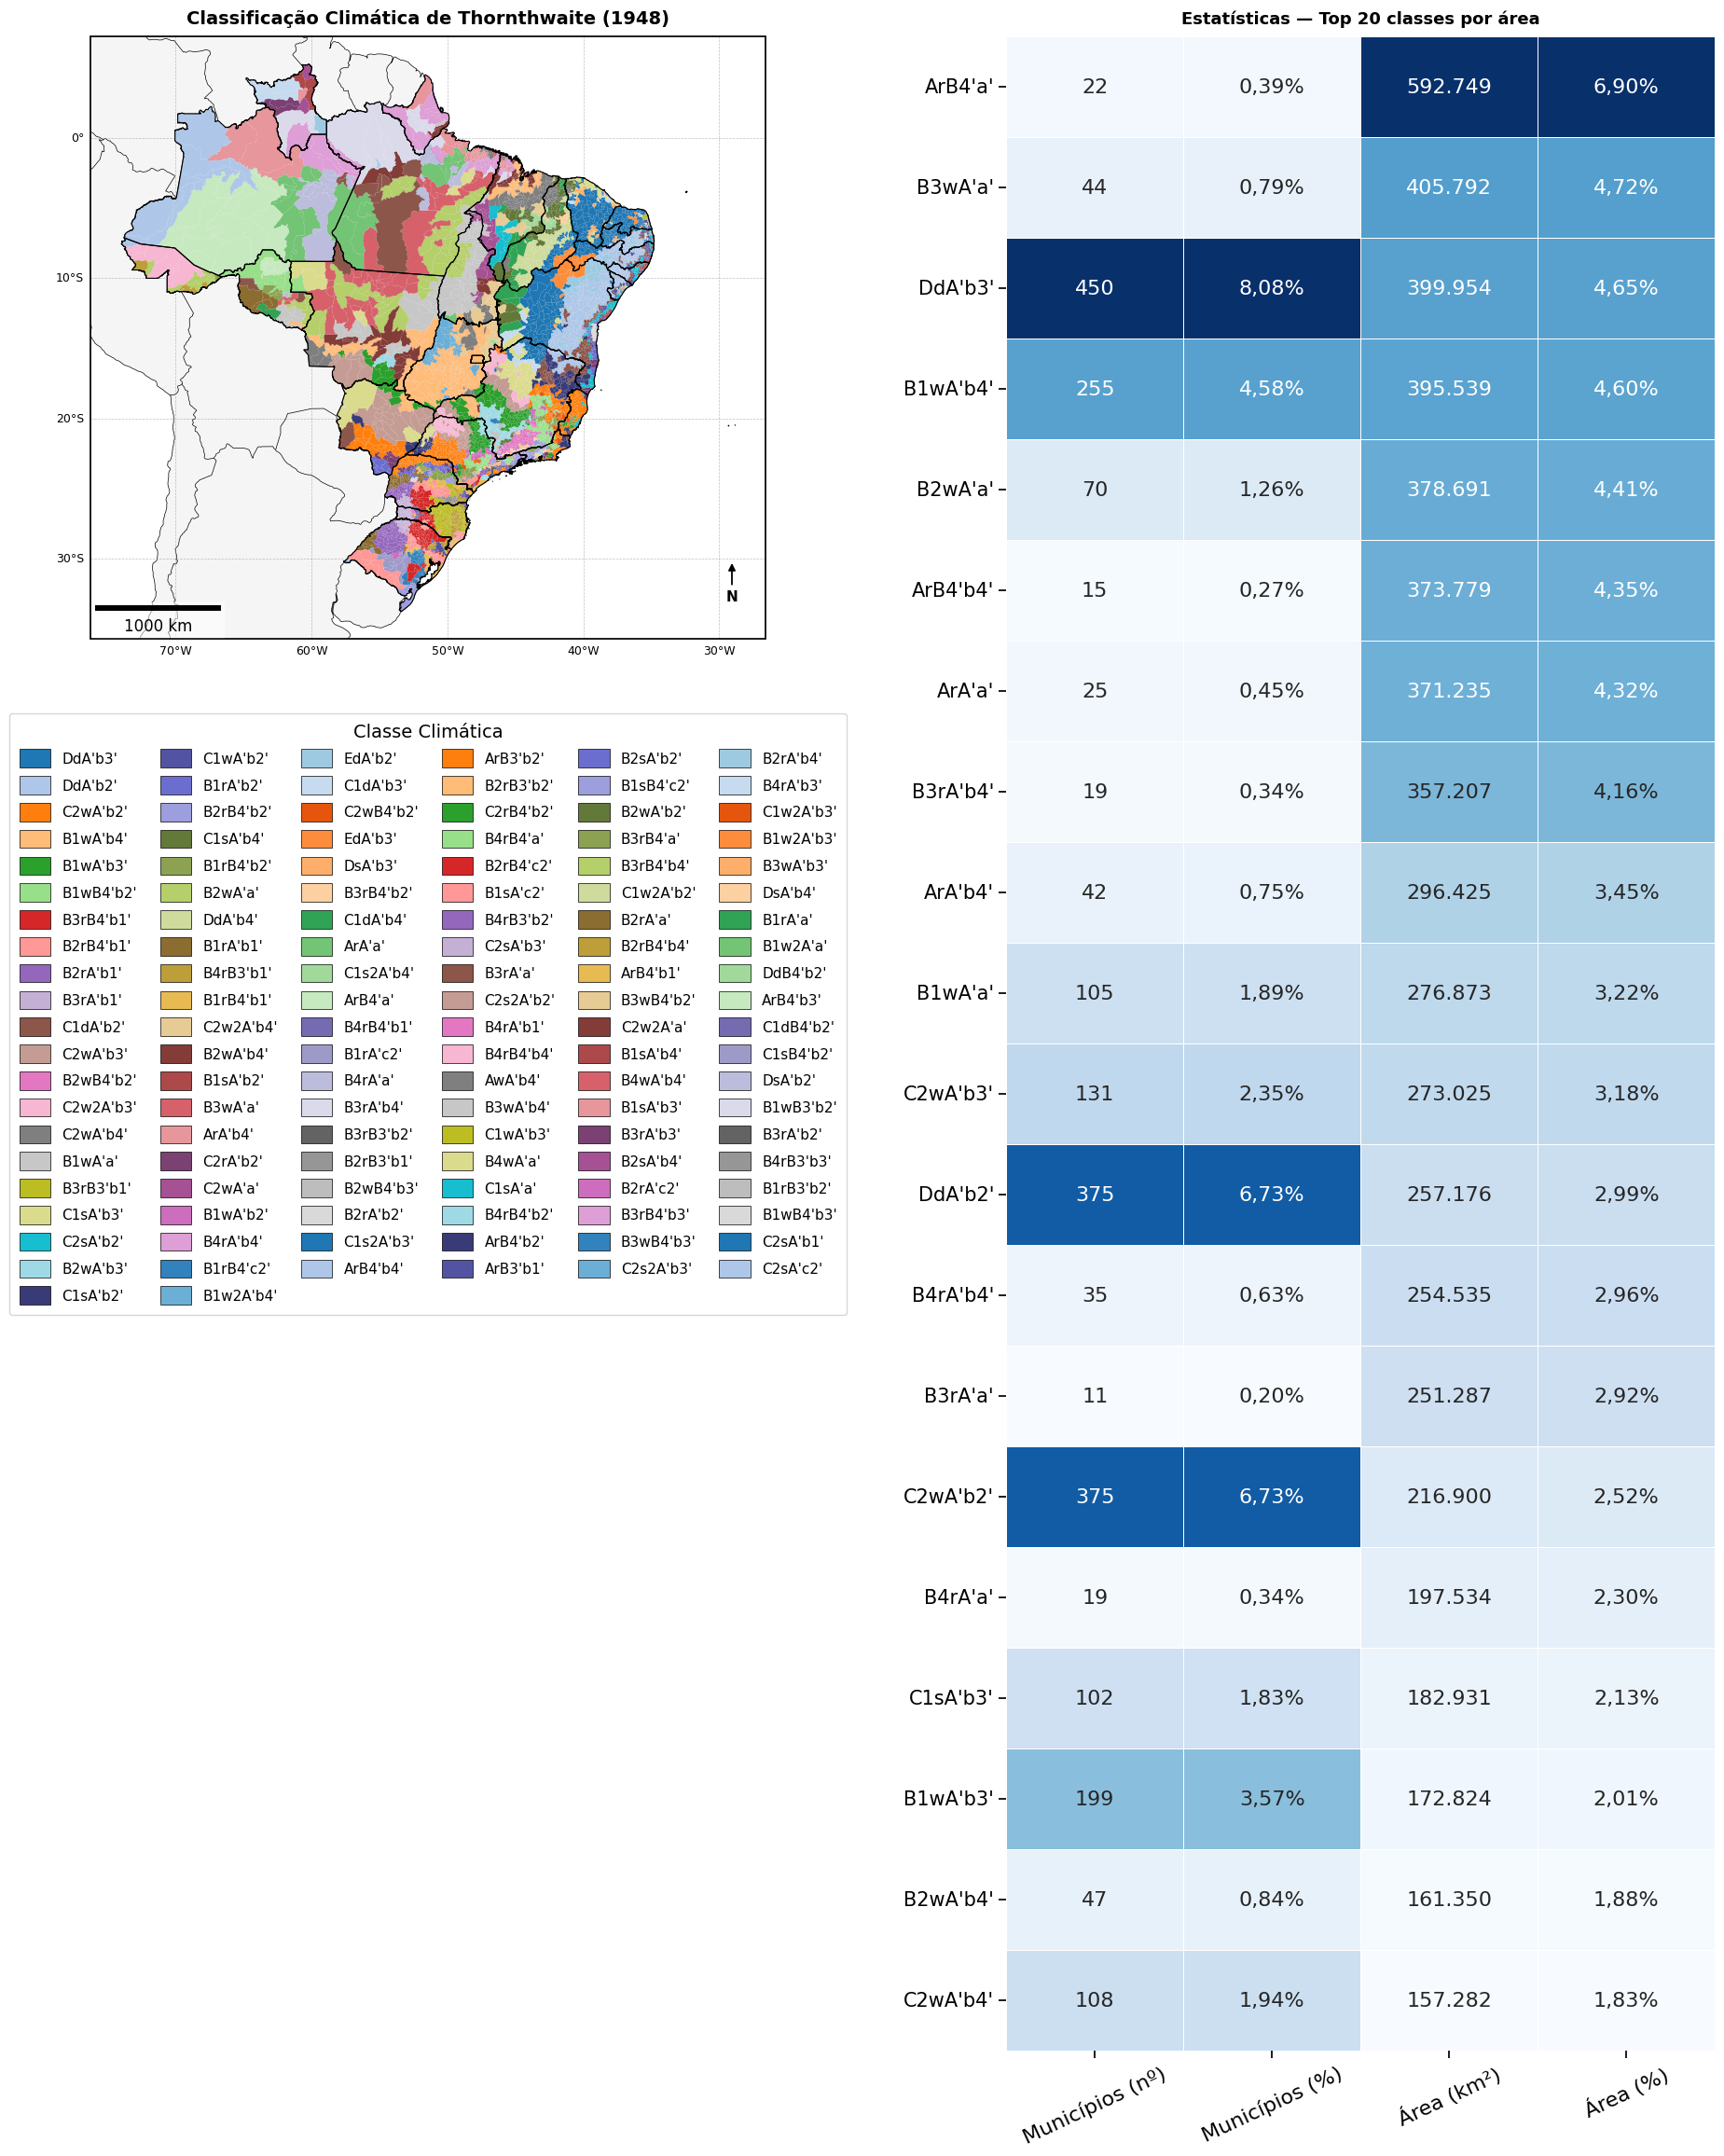

In [23]:
plot_categorico_texto_todas_heatmap_topN(
    gdf_=gdf,
    coluna_texto='thornthwaite_completo',
    titulo='Classificação Climática de Thornthwaite (1948)',
    legenda_titulo='Classe Climática',
    dados_dict=dados_thornthwaite,
    top_n=20,
    ordenar_por='area_km2',
    savepath='mapa_thornthwaite_heatmap.png'
)

### 1.3.1 Multiplot -  Thornthwaite (1948)

In [24]:
def plot_multiplot_thornthwaite(gdf_, savepath=None):
    """Painel 2x3 com as 6 variáveis contínuas do balanço hídrico de Thornthwaite:
    indice_umidade_im, indice_hidrico_ih, indice_aridez_ia, pet_anual_mm,
    excedente_anual_mm_th, def_anual_mm_th. Segue o padrão _base_map + _decoracoes,
    com colorbar individual ao lado de cada mapa."""

    vars_continuas = [
        ('indice_umidade_im',     'Índice de Umidade (Im)',            '',    'BrBG'),
        ('indice_hidrico_ih',     'Índice Hídrico (Ih)',               '',    'BrBG'),
        ('indice_aridez_ia',      'Índice de Aridez (Ia)',             '',    'YlOrRd'),
        ('pet_anual_mm',          'Evapotranspiração Potencial Anual', 'mm',  'YlGnBu'),
        ('excedente_anual_mm_th', 'Excedente Hídrico Anual',           'mm',  'GnBu'),
        ('def_anual_mm_th',       'Deficiência Hídrica Anual',         'mm',  'YlOrRd'),
    ]

    faltando = [col for col, *_ in vars_continuas if col not in gdf_.columns]
    if faltando:
        raise ValueError(f'Colunas ausentes no gdf_ passado: {faltando}')

    fig = plt.figure(figsize=(18, 11))
    gs = fig.add_gridspec(2, 3, hspace=0.28, wspace=0.20)

    for i, (col, titulo, unidade, cmap) in enumerate(vars_continuas):
        row, col_idx = divmod(i, 3)
        ax = fig.add_subplot(gs[row, col_idx], projection=ccrs.PlateCarree())
        minx, miny, maxx, maxy = _base_map(ax, titulo)

        vmin, vmax = gdf_[col].min(), gdf_[col].max()
        gdf_.plot(ax=ax, column=col, cmap=cmap, vmin=vmin, vmax=vmax,
                  edgecolor='none', transform=ccrs.PlateCarree(), zorder=3)

        _decoracoes(ax, minx, miny, maxx, maxy)
        ax.set_title(titulo, fontsize=12, fontweight='bold', pad=8)

        sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
        cb = plt.colorbar(sm, ax=ax, shrink=0.75, pad=0.03, fraction=0.05)
        if unidade:
            cb.set_label(unidade, fontsize=9)
        cb.ax.tick_params(labelsize=8)

    fig.suptitle('Variáveis do Balanço Hídrico — Classificação de Thornthwaite',
                 fontsize=16, fontweight='bold', y=0.93)

    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

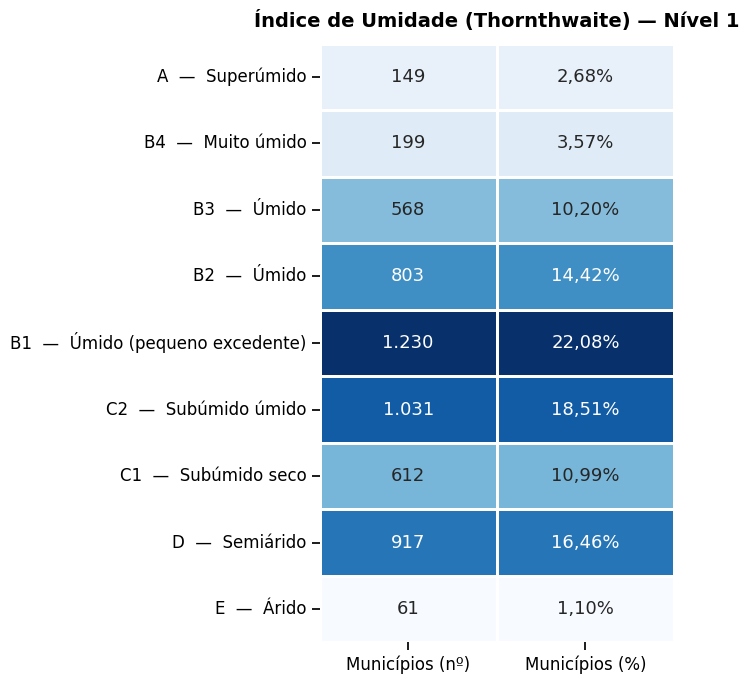

In [25]:
dados_thornthwaite_nivel1 = {
    'A':  {'categoria': 'Superúmido',             'n_municipios': 149,  'pct_municipios': 2.68},
    'B4': {'categoria': 'Muito úmido',             'n_municipios': 199,  'pct_municipios': 3.57},
    'B3': {'categoria': 'Úmido',                   'n_municipios': 568,  'pct_municipios': 10.20},
    'B2': {'categoria': 'Úmido',                   'n_municipios': 803,  'pct_municipios': 14.42},
    'B1': {'categoria': 'Úmido (pequeno excedente)','n_municipios': 1230, 'pct_municipios': 22.08},
    'C2': {'categoria': 'Subúmido úmido',          'n_municipios': 1031, 'pct_municipios': 18.51},
    'C1': {'categoria': 'Subúmido seco',           'n_municipios': 612,  'pct_municipios': 10.99},
    'D':  {'categoria': 'Semiárido',               'n_municipios': 917,  'pct_municipios': 16.46},
    'E':  {'categoria': 'Árido',                   'n_municipios': 61,   'pct_municipios': 1.10},
}

def plot_heatmap_thornthwaite_nivel1(dados_dict, titulo='Índice de Umidade (Thornthwaite) — Nível 1',
                                      savepath=None, cmap='Blues', figsize=(7, 7),
                                      fontsize_annot=13, fontsize_labels=12, fontsize_title=14):
    df = pd.DataFrame(dados_dict).T
    df['n_municipios'] = df['n_municipios'].astype(int)
    df['pct_municipios'] = df['pct_municipios'].astype(float)

    # Rótulo do eixo Y: "Classe — Categoria"
    y_labels = [f"{idx}  —  {row['categoria']}" for idx, row in df.iterrows()]

    df_plot = df[['n_municipios', 'pct_municipios']].astype(float)

    df_norm = df_plot.copy()
    for col in df_norm.columns:
        cmin, cmax = df_norm[col].min(), df_norm[col].max()
        df_norm[col] = (df_norm[col] - cmin) / (cmax - cmin) if cmax > cmin else 0.5

    annot = pd.DataFrame(index=df_plot.index, columns=df_plot.columns, dtype=object)
    annot['n_municipios'] = df_plot['n_municipios'].apply(lambda x: f'{int(x):,}'.replace(',', '.'))
    annot['pct_municipios'] = df_plot['pct_municipios'].apply(lambda x: f'{x:.2f}'.replace('.', ',') + '%')

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(df_norm, annot=annot.values, fmt='', cmap=cmap, cbar=False,
                linewidths=0.8, linecolor='white', ax=ax,
                xticklabels=['Municípios (nº)', 'Municípios (%)'],
                yticklabels=y_labels, annot_kws={'fontsize': fontsize_annot})

    ax.set_title(titulo, fontsize=fontsize_title, fontweight='bold', pad=12)
    ax.tick_params(axis='x', rotation=0, labelsize=fontsize_labels)
    ax.tick_params(axis='y', rotation=0, labelsize=fontsize_labels)

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()


plot_heatmap_thornthwaite_nivel1(dados_thornthwaite_nivel1, savepath='heatmap_thornthwaite_nivel1.png')

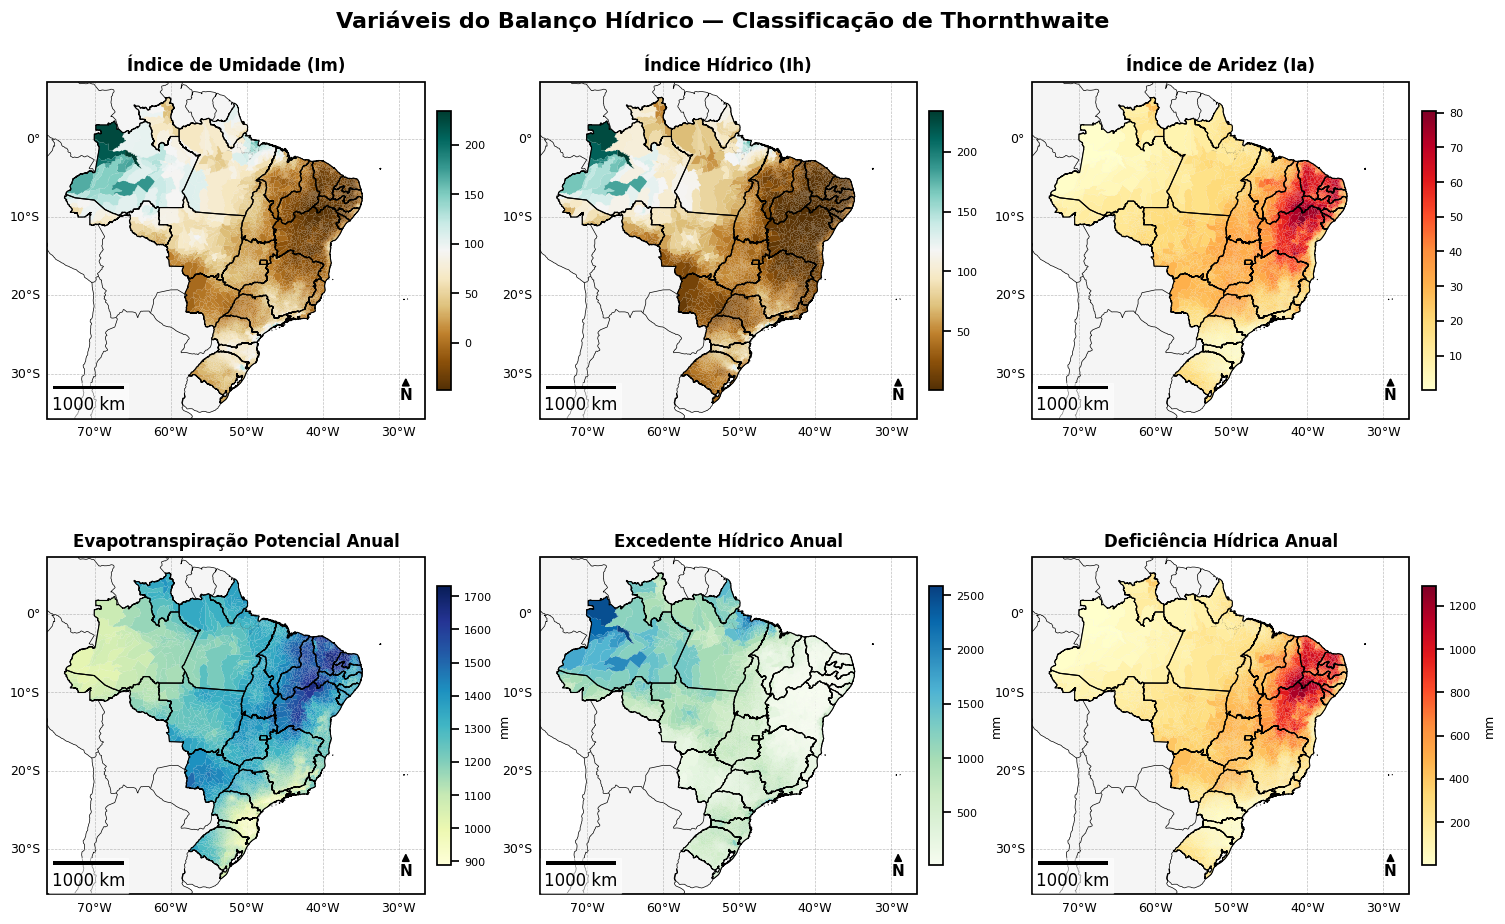

In [26]:
warnings.filterwarnings("ignore")
plot_multiplot_thornthwaite(gdf, savepath='multiplot_thornthwaite.png')